In [1]:
from SFstarred.DataStarred import DataStarred
import matplotlib.pyplot as plt
#from matplotlib.scolors import SymLogNorm, LogNorm, Normalize, TwoSlopeNorm
import numpy as np
from copy import deepcopy
from starred.procedures.deconvolution_routines import multi_steps_deconvolution

/Users/felavila/miniconda3/envs/SFstarred/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

## Overview

In this notebook, I summarize the main features used to read HST images, select lens systems, cut out stars, and save the resulting data products.

In [23]:
path_data = "/home/felipe/work/MyPackages/DAHAD/examples/WISEJ0259/mastDownload/JWST/jw02046-o003_t003_miri_f560w/jw02046-o003_t003_miri_f560w_i2d.fits"
#path_data = "/home/felipe/work/StrongLensingModeling/SFstarred/notebooks/HST_IMAGES_0214_2105/WG0214-2105_F160W_drz_sci.fits"
#path_data = "/home/felipe/work/Data/mast_data/WFIJ2033/JWST/mastDownload/JWST/jw01198-o004_t004_nircam_clear-f115w/jw01198-o004_t004_nircam_clear-f115w_i2d.fits"
#remove_star: 5 (light contamination from other source), 8 (it is one of the QSO images); 9 (large residuals) 
data_F160W = DataStarred(path_data)

Set DATE-AVG to '2023-07-30T20:52:50.434' from MJD-AVG.
Set DATE-END to '2023-07-30T20:54:42.802' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -33.700495 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694646708.745 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [24]:
# with fits.open(path_data) as hdul:
#     hdul.info()

In [30]:
data_F160W.matched_b

AttributeError: 'DataStarred' object has no attribute 'matched_b'

for the cut out

values use for fwhm = 5 and threshold = 21.9568983289851


<Axes: >

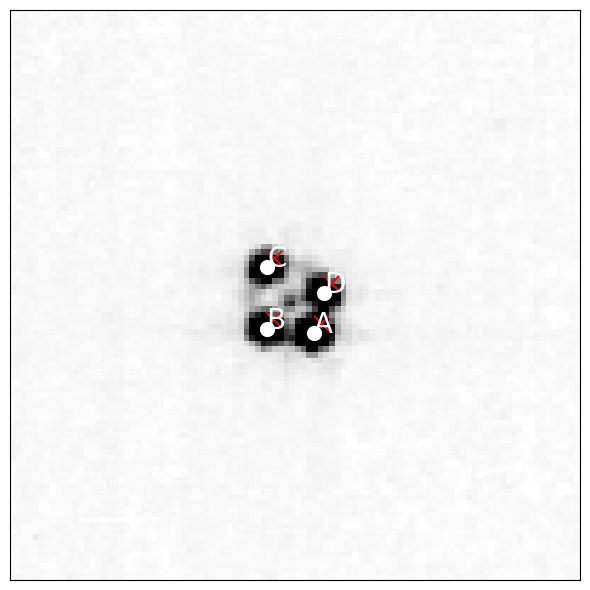

In [25]:
data_F160W.cut_out_lens(plot=True, refine_centers=True, centroid_box_size=7, centroid_method="2dg",num_pix=100)

In [26]:
data_F160W.std

np.float64(0.43913796657970205)

Multiples ways to detect stars

The search for stars will be with detec_fwhm = 5.000 and threshold = 21.957
Refined 1 star centers. Failed: 0
Detected 1 stars outside the object region.


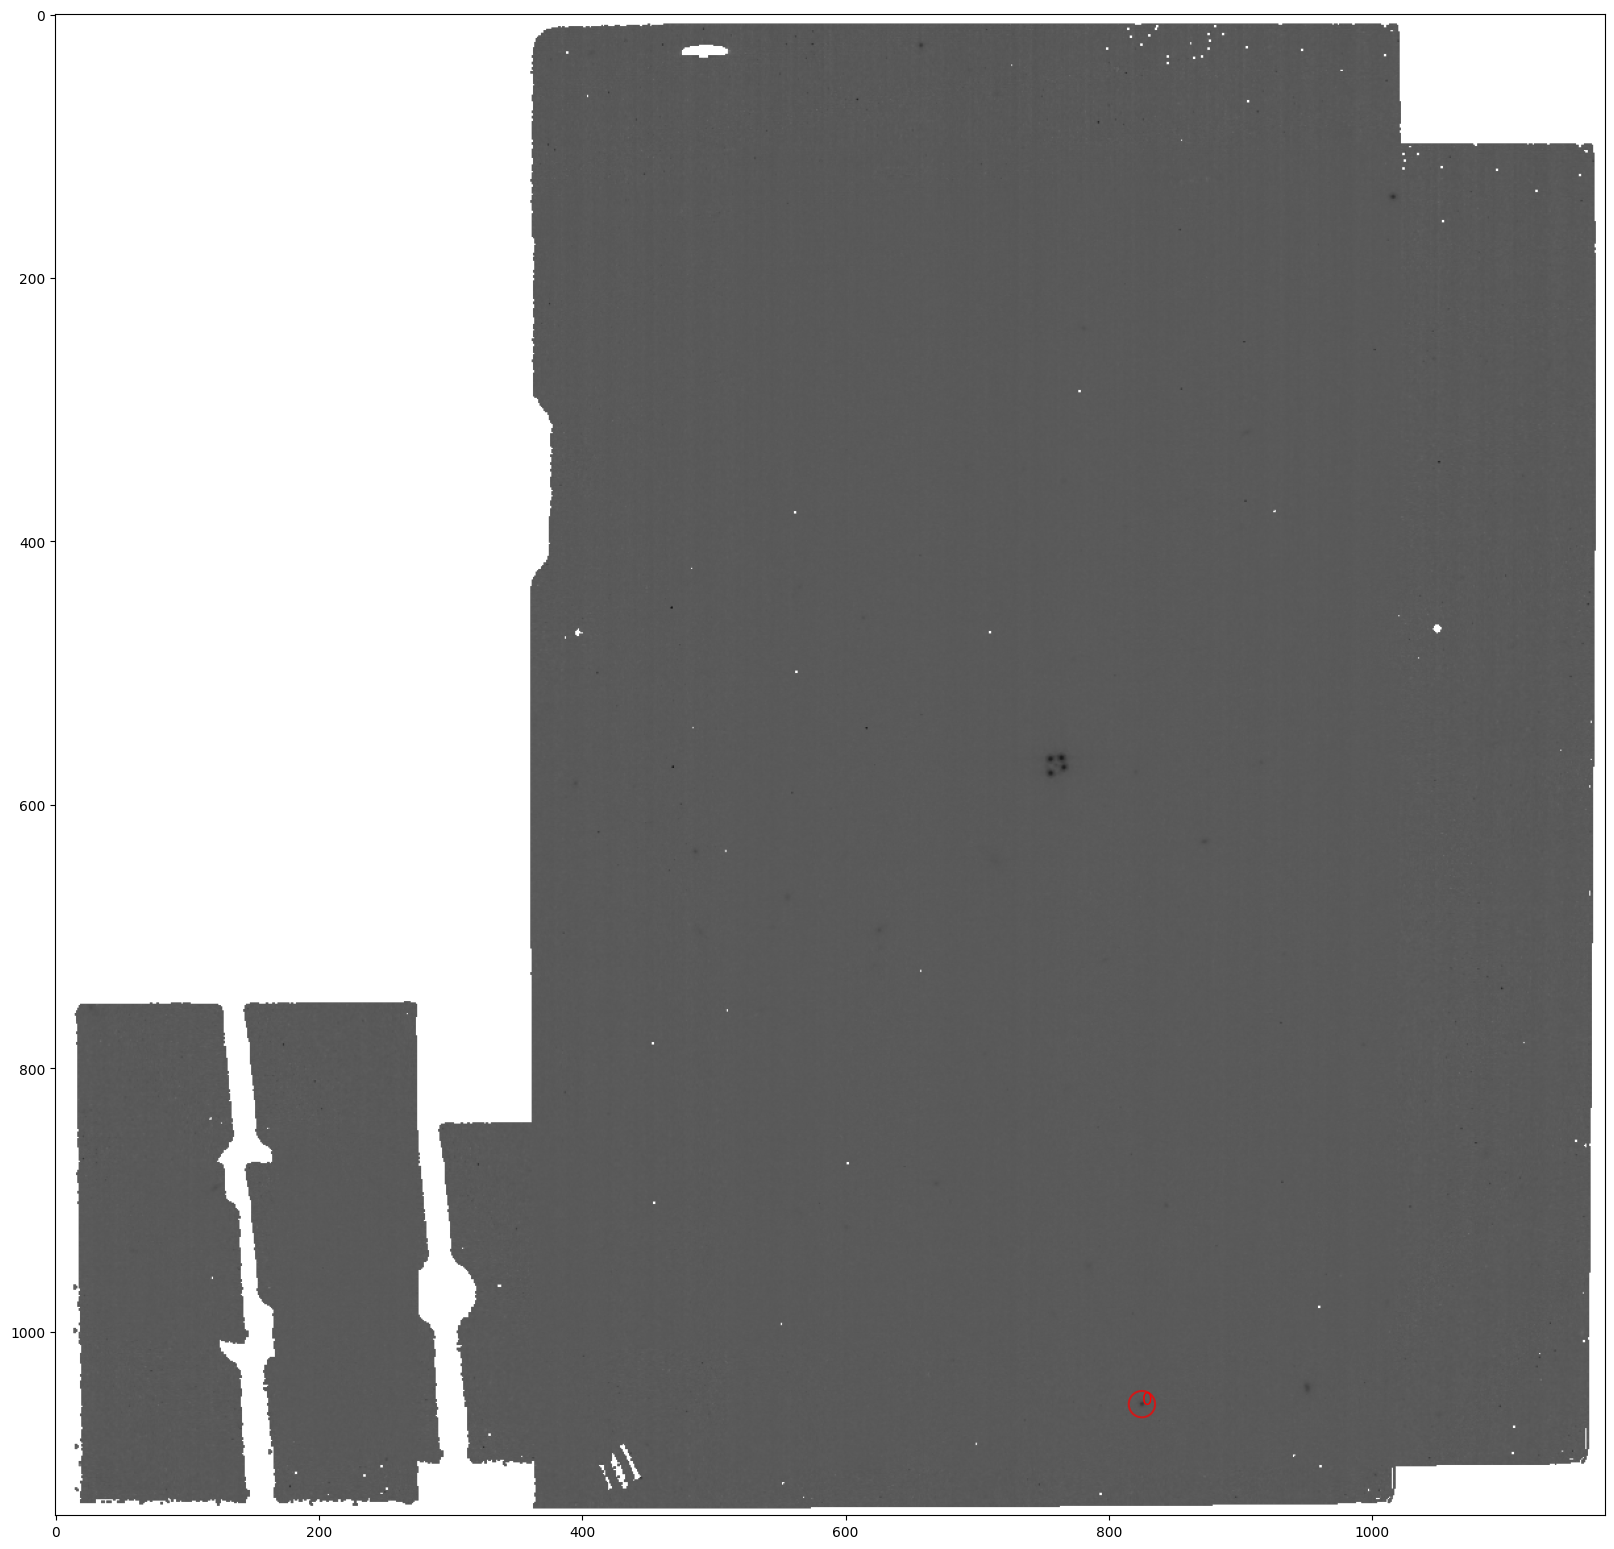

In [29]:
stat_stars = data_F160W.detect_stars(star_num_pix=40,detec_fwhm=None,threshold=None,verbose=True,make_plots=True,
                                     n_keep=20,
                                     binary_dilation_iteration=20,use_gaia=True,
                                     gaia_gmag_limit=20,gaia_radius=None,)

In [289]:
# stat_stars = data_F160W.detect_stars(detec_fwhm=None,threshold=None,verbose=True,make_plots=True,save=False,path_filter=None,star_num_pix=41,n_keep=20,binary_dilation_iteration=20,use_gaia=False,gaia_gmag_limit=20,gaia_radius=None,)

check the stars with 

ra, dec: [308.40949948 -47.40781447]


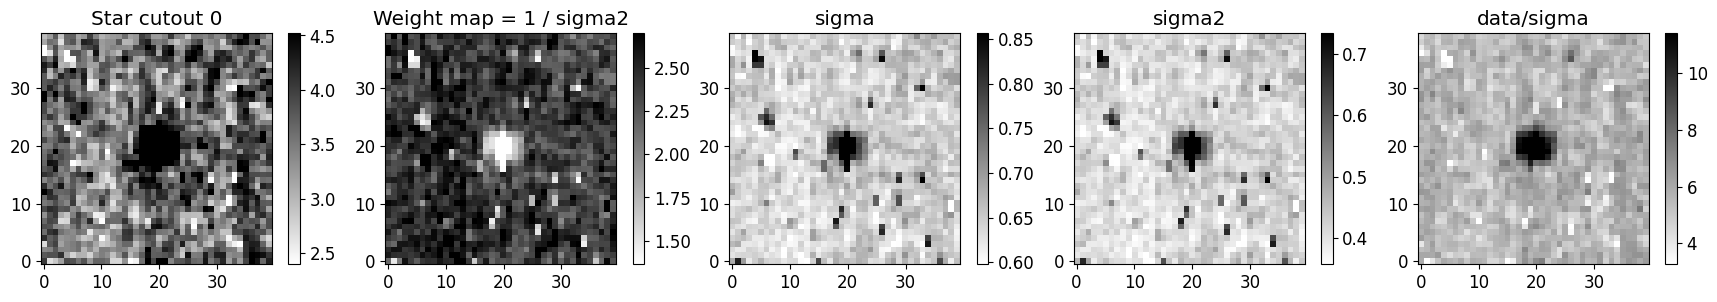

ra, dec: [308.40151591 -47.37598163]


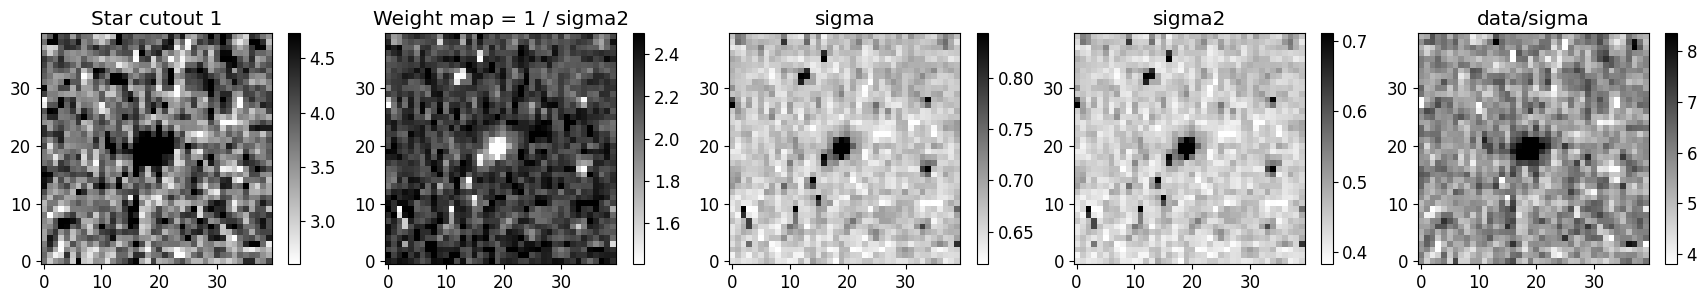

ra, dec: [308.41647795 -47.38813221]


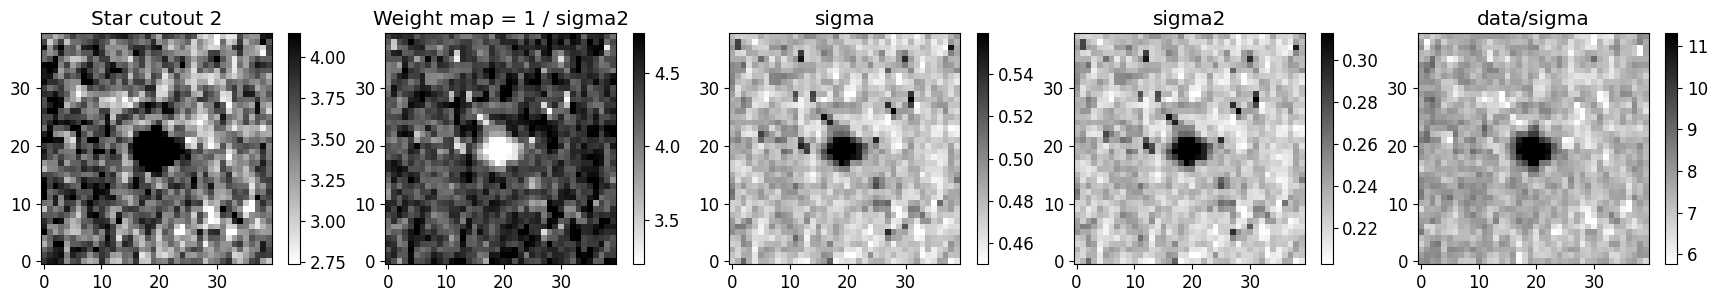

ra, dec: [308.41992444 -47.39138187]


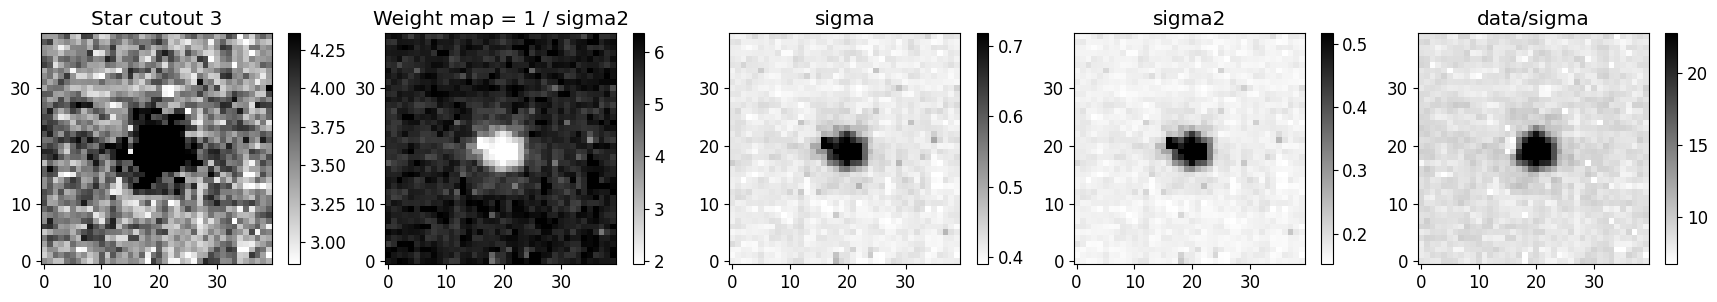

In [290]:
data_F160W.plot_stars()

In [291]:
# data_F160W.recut_stars(110)

ra, dec: [308.40949948 -47.40781447]


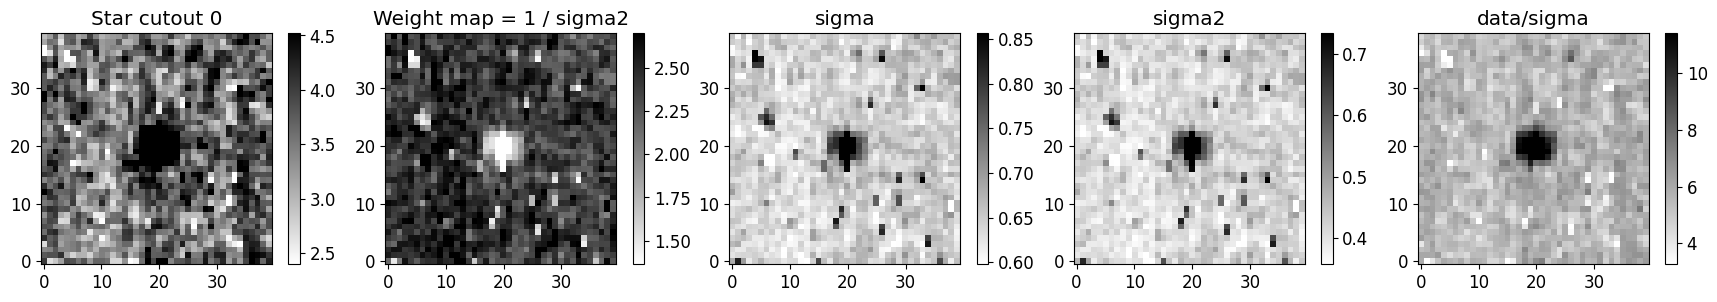

ra, dec: [308.41647795 -47.38813221]


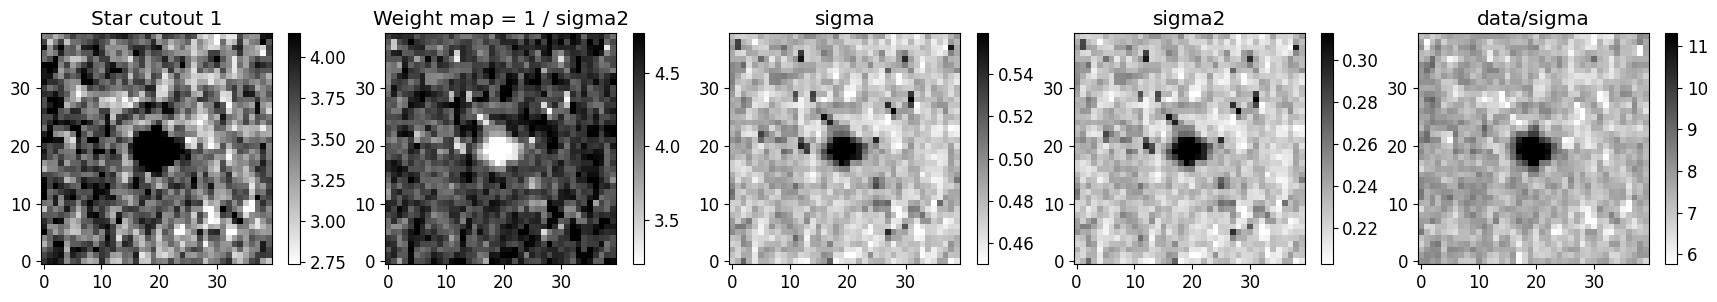

ra, dec: [308.41992444 -47.39138187]


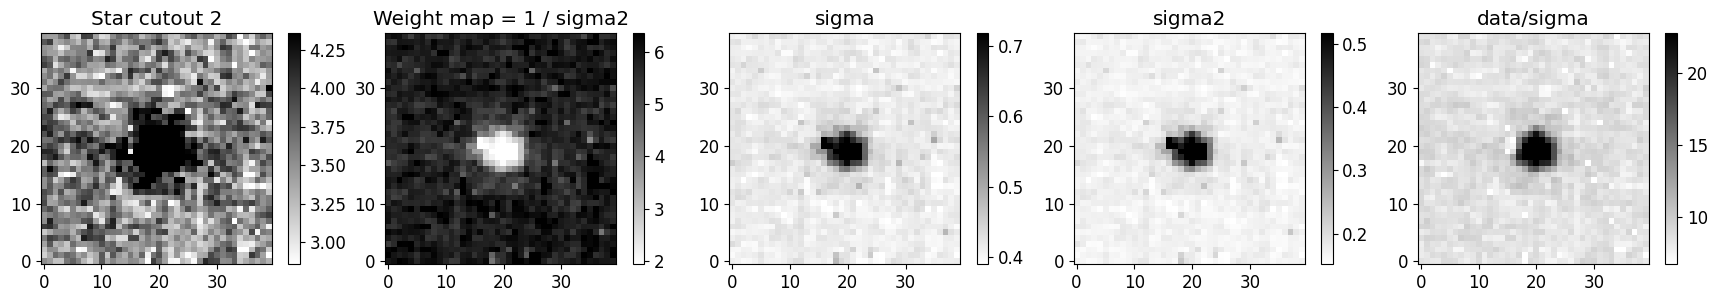

In [293]:
dict_result = data_F160W.save_for_starred(do_plots=True,non_selected_stars_index=[1],verbose=False,save_path=f"data_for_starred/{data_F160W.FILTER}/data_for_starred_{data_F160W.FILTER}_WFIJ2033.pickle")

In [294]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from starred.deconvolution.deconvolution import Deconv, setup_model
from starred.deconvolution.loss import Loss as decLoss
from starred.deconvolution.parameters import ParametersDeconv
from starred.utils.noise_utils import propagate_noise
from starred.optim.optimization import Optimizer
from starred.plots import plot_function as pltf

from starred.psf.psf import PSF, load_PSF_model
from starred.psf.loss import Loss
from starred.psf.parameters import ParametersPSF

from starred.utils import ds9reg
from starred.utils.noise_utils import propagate_noise
from starred.procedures.psf_routines import run_multi_steps_PSF_reconstruction
from SFstarred.plots import plot_image_and_noisemap

In [295]:
# a function that generates a model instance and initial guess parameters:
from starred.deconvolution.deconvolution import setup_model
# a parameters handler:
from starred.deconvolution.parameters import ParametersDeconv
# the loss function, basically chi² + regularization
from starred.deconvolution.loss import Loss
# the interface to the optimizer:
from starred.optim.optimization import Optimizer
# a way to propagate the noisemap through starlet layers:
from starred.utils.noise_utils import propagate_noise
# a plot utility to explore our deconvolution at every step
from starred.plots.plot_function import view_deconv_model
from starred.plots.plot_function import view_deconv_model, plot_loss, plot_deconvolution

In [296]:
def save_stars_for_region_masks(
    stars_data,
    stars_sigma2=None,
    selected_star_indices=None,
    output_dir="stars_for_masks",
    overwrite=True,
):
    """
    Save each selected PSF star cutout as an individual FITS file.

    These FITS files can be opened in DS9 to manually create region masks.

    Parameters
    ----------
    stars_data : array-like
        Array with shape ``(N_stars, ny, nx)`` containing the star cutouts.

    stars_sigma2 : array-like, optional
        Array with shape ``(N_stars, ny, nx)`` containing the variance maps.
        If given, it is saved as an additional FITS extension.

    selected_star_indices : list of int, optional
        Original indices of the selected stars. If given, these are saved
        in the FITS header.

    output_dir : str, optional
        Directory where the FITS files will be saved.

    overwrite : bool, optional
        If True, overwrite existing FITS files.

    Returns
    -------
    saved_files : list of str
        Paths to the saved FITS files.
    """
    import os 
    from astropy.io import fits 
    os.makedirs(output_dir, exist_ok=True)

    stars_data = np.asarray(stars_data)

    if stars_sigma2 is not None:
        stars_sigma2 = np.asarray(stars_sigma2)

    saved_files = []

    for j in range(stars_data.shape[0]):
        if selected_star_indices is not None:
            original_index = selected_star_indices[j]
        else:
            original_index = j

        filename = os.path.join(output_dir, f"star_{original_index}.fits")

        header = fits.Header()
        header["STARID"] = int(original_index)
        header["COMMENT"] = "Open this file in DS9 and save mask as mask_STARID.reg"

        primary_hdu = fits.PrimaryHDU(data=stars_data[j], header=header)
        hdus = [primary_hdu]

        if stars_sigma2 is not None:
            sigma2_hdu = fits.ImageHDU(
                data=stars_sigma2[j],
                name="SIGMA2",
            )
            hdus.append(sigma2_hdu)

        hdul = fits.HDUList(hdus)
        hdul.writeto(filename, overwrite=overwrite)

        saved_files.append(filename)

    print(f"Saved {len(saved_files)} star FITS files in: {output_dir}")

    return saved_files

In [297]:
# dict_result = pd.read_pickle("/home/felipe/work/StrongLensingModeling/SFstarred/notebooks/other_experiments/data_for_starred/F115W/data_for_starred_F115W_WFIJ2033.pickle")

In [298]:
# dict_result_read.keys()

In [299]:
# dict_result_read.keys()

In [300]:


#convolution_method = 'scipy'#'fft'#'scipy'  #fft is better on CPU
#
# Stars normalize, norm factor and sigma_2 normalize by norm**2
remove_stars_index = []
stars_data = np.array([dict_result["stars_data"][i] for i in range(dict_result["stars_data"].shape[0]) if i not in remove_stars_index])
stars_sigma2 = np.array([dict_result["stars_sigma2"][i] for i in range(dict_result["stars_data"].shape[0]) if i not in remove_stars_index])



In [301]:
stars_data.shape

(3, 40, 40)

In [302]:
save_stars_for_region_masks(stars_data,output_dir=f"data_for_starred/{data_F160W.FILTER}/stars_for_masks")

Saved 3 star FITS files in: data_for_starred/F560W/stars_for_masks


['data_for_starred/F560W/stars_for_masks/star_0.fits',
 'data_for_starred/F560W/stars_for_masks/star_1.fits',
 'data_for_starred/F560W/stars_for_masks/star_2.fits']

In [314]:
from SFstarred.stars_cut import normalize_data_error
from SFstarred.plots import twoplot
norm_factor,stars_data,stars_sigma2,*_, = normalize_data_error(stars_data,1/stars_sigma2,print_=False)#stars

In [315]:
from SFstarred.plots import plot_image_with_scalebar,plot_stars_features

In [316]:
# norm = stars_sigma2[0].max() / 100.
# stars_sigma2 /= norm
# stars_sigma2 /= norm**2

In [317]:
# from SFstarred.plots import twoplot,plot_stars_features
# plot_stars_features(stars_data,stars_sigma2)

In [318]:
# 5 12 15

In [319]:
# fig = pltf.display_data(stars_norm_F160, sigma_2 = stars_sigma2_norm_F160)

In [320]:
# fig, axs = plt.subplots(1,4, figsize=(20,20))
# for ax, star, noisemap in zip(axs, stars_norm_F160, np.sqrt(stars_sigma2_norm_F160)):
#     ax.imshow(star/noisemap, cmap='gray'); ax.axis('off')
# plt.tight_layout()

In [321]:
# number of stars


# data dimensions


In [322]:
# masks[0]

In [400]:
# Setup parameters
masks = np.ones_like(stars_data, dtype=bool)

edge = 2
masks[:, :edge, :] = False
masks[:, -edge:, :] = False
masks[:, :, :edge] = False
masks[:, :, -edge:] = False

# Also mask non-finite data/noise values
masks &= np.isfinite(stars_data)
masks &= np.isfinite(stars_sigma2)
masks &= stars_sigma2 > 0

# subsampling_factor control the resolution of the reconstructed psf
subsampling_factor = 4 #this can be increased for a better resolution, try 3 or 4; should be 3 for lenstronomy
n_iter_initial = 1000 #300
n_iter = 5_000 

# increasing lambda_scales and lambda_hf will increase chi2 (they should be between 1 and 3)
lambda_scales = 3.0 # control the regularization strength for low frequencies 
lambda_hf =3.0 # (increse this) control the regularization strength for high frequencies 
lambda_positivity = 1000. #0. #penalising term if the full psf have negative pixels. Leave it to 0. in most cases to save computationnal time.
N = len(stars_data)
image_size = np.shape(stars_data)[1]
image_size_up = image_size * subsampling_factor
print(np.shape(stars_data))

convolution_method = 'fft'
regularize_full_psf = False
include_moffat = True
model = PSF(image_size=image_size, number_of_sources=N, 
            upsampling_factor=subsampling_factor, 
            convolution_method=convolution_method,
            include_moffat = include_moffat)
kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(stars_data, fixed_background=False,
                                                                          guess_method='barycenter')
parameters = ParametersPSF(kwargs_init, kwargs_fixed, kwargs_up, kwargs_down)

fitting_sequence = [['background'], ['moffat']]
method_noise = "MC" # "SLIT" #
#'Newton-CG' reduce todo ? 
optim_list = ['Newton-CG', 'adabelief']
kwargs_optim_list = [{'maxiter': n_iter_initial}, \
                     {'max_iterations': n_iter, 'min_iterations': None, \
                      'init_learning_rate': 0.01, \
                        'schedule_learning_rate': True, 'restart_from_init': False, \
                            'stop_at_loss_increase': False, 'progress_bar': True, \
                                'return_param_history': True},]
model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = run_multi_steps_PSF_reconstruction(
        stars_data, model,
        parameters, stars_sigma2, masks=masks.astype(np.float64),
        lambda_scales=lambda_scales, lambda_hf=lambda_hf,
        lambda_positivity=lambda_positivity,
        fitting_sequence=fitting_sequence,
        optim_list=optim_list,
        kwargs_optim_list=kwargs_optim_list,
        method_noise=method_noise, regularize_full_psf=regularize_full_psf,
        verbose=True)




(3, 40, 40)
### Step 1, fixing : ['background'] ###


/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/optim/optimization.py:181: UserWarning: You are using an unconstrained optimiser. Bounds are ignored.
  warnings.warn('You are using an unconstrained optimiser. Bounds are ignored.')


/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/utils/noise_utils.py:53: RuntimeWarning: Mean of empty slice
  noise_map = np.nanmean(centered_masked_noise_maps, axis=0)


Step 1/2 took 91 seconds
Kwargs partial at step 1/2 {'kwargs_moffat': {'fwhm': Array([0.02985835], dtype=float32), 'beta': Array([0.3023762], dtype=float32), 'C': Array([177.5978], dtype=float32)}, 'kwargs_gaussian': {'a': Array([175.92117, 164.03716, 192.80847], dtype=float32), 'x0': Array([0.50459397, 0.17660806, 0.345748  ], dtype=float32), 'y0': Array([ 0.28055274, -0.400857  , -0.33596435], dtype=float32)}, 'kwargs_background': {'background': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32), 'mean': Array([0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  1884.6631
Overall Reduced Chi2 :  0.78527623
### Step 2, fixing : ['moffat'] ###


optax.adabelief: 100%|██████████| 5000/5000 [04:05<00:00, 20.40it/s] 


Step 2/2 took 247 seconds
Kwargs partial at step 2/2 {'kwargs_moffat': {'fwhm': Array([0.02985835], dtype=float32), 'beta': Array([0.3023762], dtype=float32), 'C': Array([177.5978], dtype=float32)}, 'kwargs_gaussian': {'a': Array([277.71368, 268.8211 , 284.00668], dtype=float32), 'x0': Array([ 0.54113007, -0.02083498,  0.9667309 ], dtype=float32), 'y0': Array([ 0.30278623, -0.26513624, -0.27477518], dtype=float32)}, 'kwargs_background': {'background': Array([ 0.00118104,  0.00026399, -0.00412212, ..., -0.00377984,
       -0.00329027, -0.00226146], dtype=float32), 'mean': Array([0., 0., 0.], dtype=float32)}, 'kwargs_distortion': {'dilation_x': Array([0., 0.], dtype=float32), 'dilation_y': Array([0., 0.], dtype=float32), 'shear': Array([0., 0.], dtype=float32)}}
LogL :  725.8936
Overall Reduced Chi2 :  0.20768929


array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        ...,
        [0., 0., 1., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        ...,
        [0., 0., 1., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 1., 0., 0.],
        ...,
        [0., 0., 1., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]], shape=(3, 40, 40))

Moffat fit :


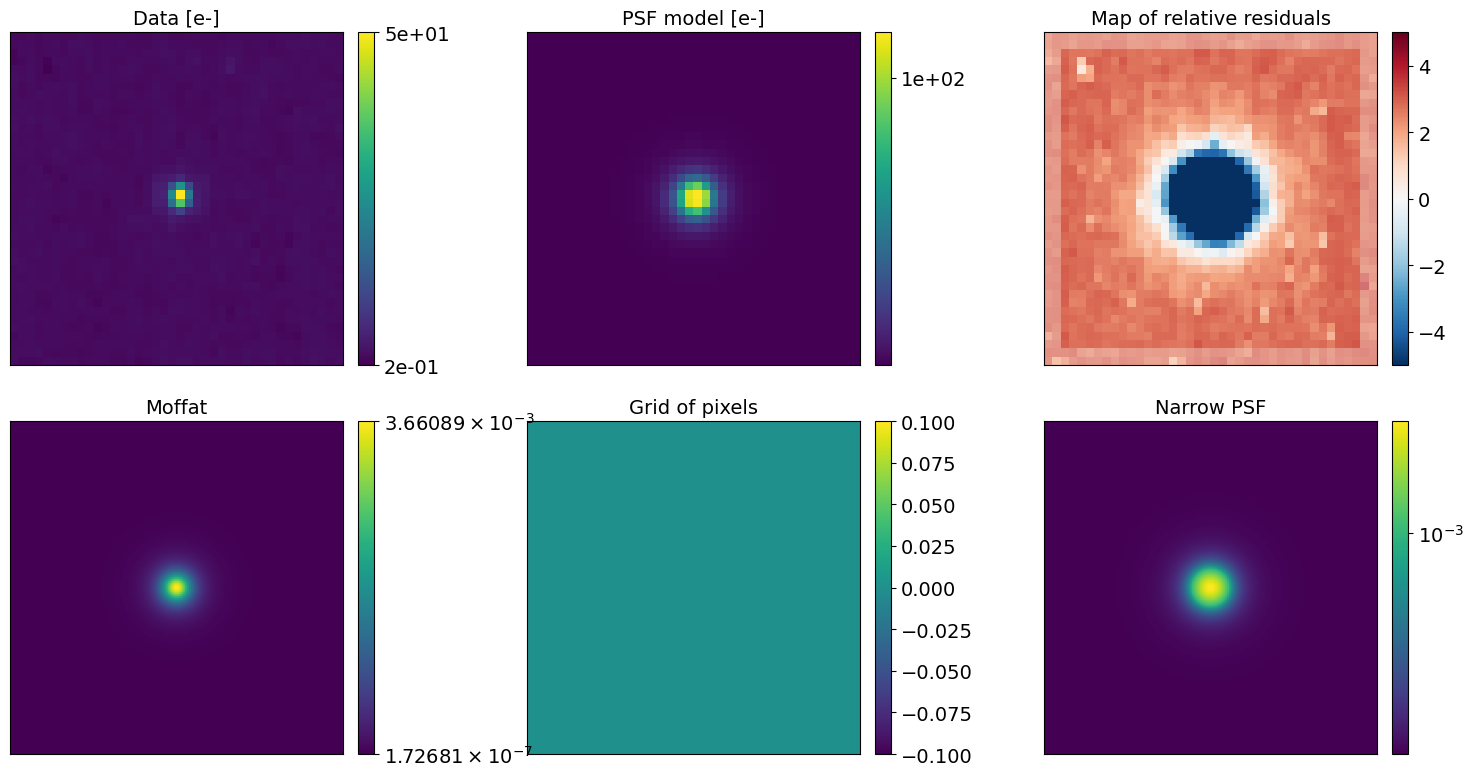

Moffat+ Background fit :


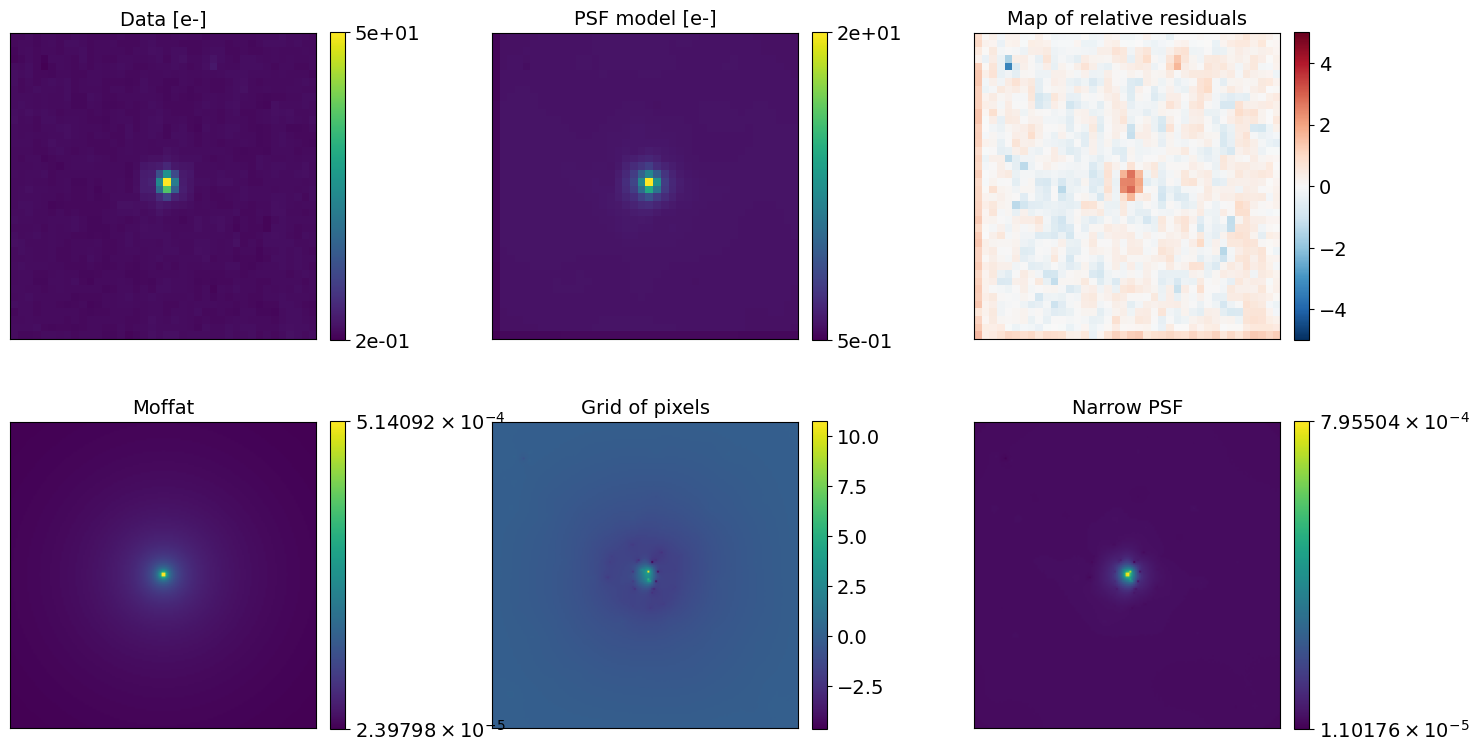

Multiple stars PSF model :


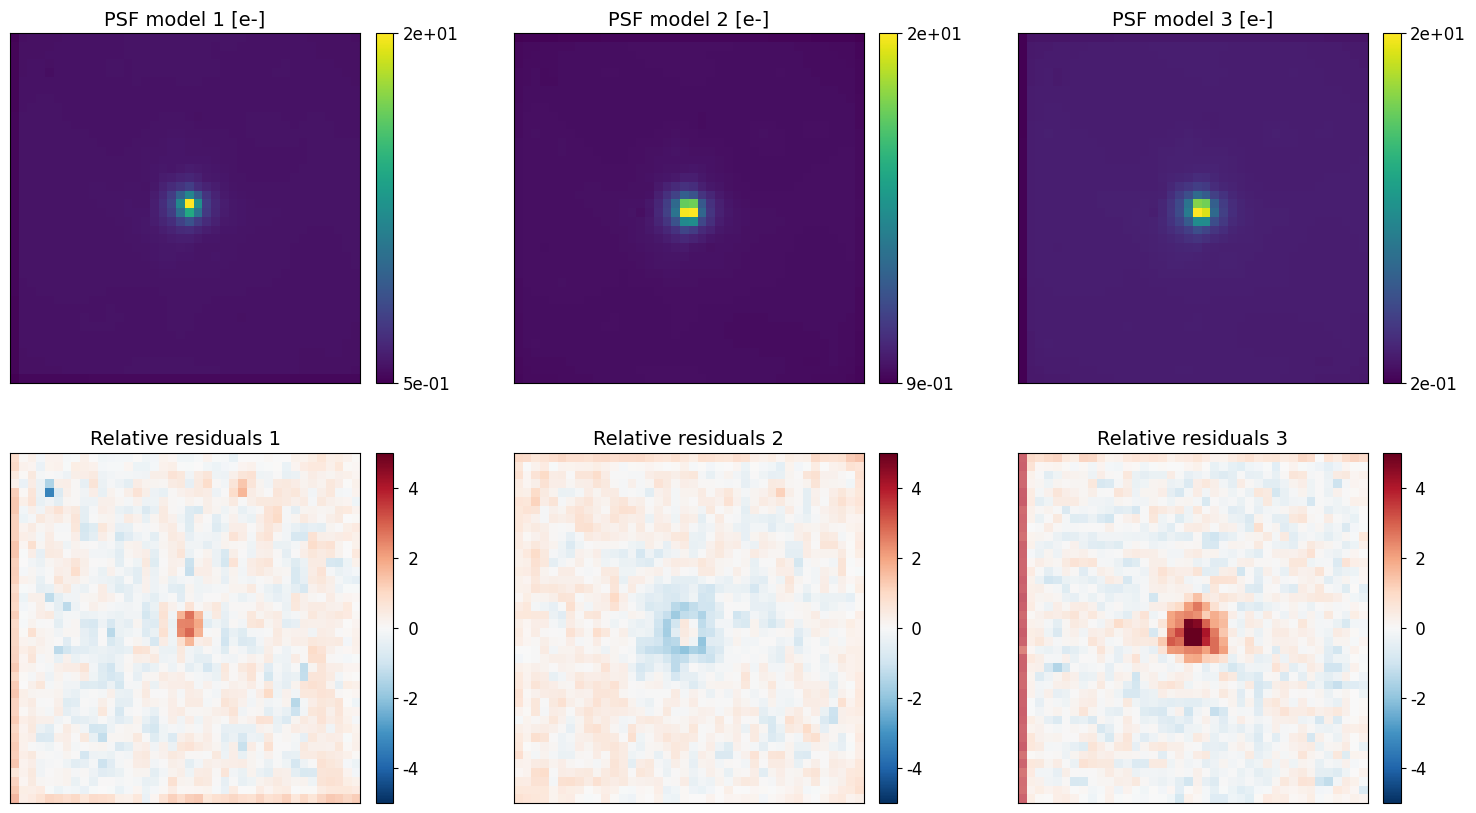

Loss history :


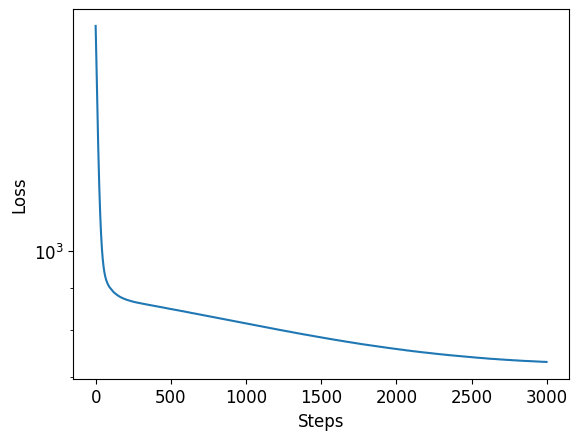

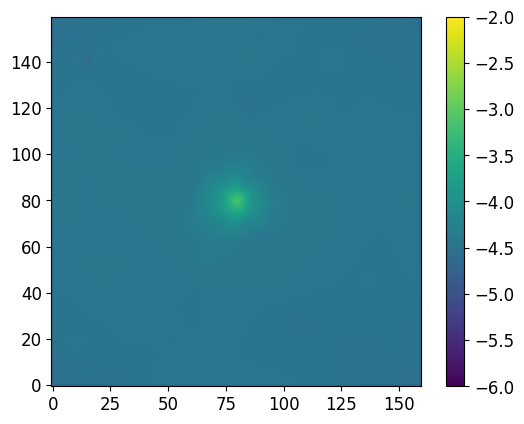

In [324]:
kwargs_final = kwargs_partial_list[-1]

fig1 = pltf.single_PSF_plot(model, stars_data, stars_sigma2, kwargs_partial_list[0],masks=masks.astype(np.float64), n_psf=0, units='e-')
print('Moffat fit :')
plt.show(fig1)
fig2 = pltf.single_PSF_plot(model,stars_data, stars_sigma2, kwargs_final, n_psf=0,masks=masks.astype(np.float64), units='e-')
print('Moffat+ Background fit :')
plt.show(fig2)
fig3 = pltf.multiple_PSF_plot(model,stars_data, stars_sigma2, kwargs_final,masks=masks.astype(np.float64),units='e-')
print('Multiple stars PSF model :')
plt.show(fig3)

fig, ax = plt.subplots(1,1)
ax.plot(range(len(loss_history_list[-1])), loss_history_list[-1])
ax.set_xlabel('Steps')
ax.set_ylabel('Loss')
ax.set_yscale('log')
print('Loss history :')
plt.show(fig)
full_psf = model.get_full_psf(**kwargs_final)

fig5 = plt.figure()
plt.imshow(np.nan_to_num(np.log10(full_psf), nan=-10), origin='lower', vmin=-6, vmax=-2)
plt.colorbar()

In [325]:
# subsampling_factor = 3
# n_iter_initial = 1000
# n_iter = 3000

# # For debugging, start with weak regularization
# lambda_scales = 0.5
# lambda_hf = 0.5
# lambda_positivity = 0.0

# convolution_method = "fft"
# regularize_full_psf = False
# include_moffat = True
# method_noise = "MC"

# N = len(stars_data)
# image_size = stars_data.shape[1]
# image_size_up = image_size * subsampling_factor

# print("stars_data shape:", stars_data.shape)
# print("stars_sigma2 shape:", stars_sigma2.shape)
# print("image_size:", image_size)
# print("image_size_up:", image_size_up)
# print("N stars:", N)


# # ============================================================
# # 2. Optional: mask bad edges
# # ============================================================

# masks = np.ones_like(stars_data, dtype=bool)

# edge = 2
# masks[:, :edge, :] = False
# masks[:, -edge:, :] = False
# masks[:, :, :edge] = False
# masks[:, :, -edge:] = False

# # Also mask non-finite data/noise values
# masks &= np.isfinite(stars_data)
# masks &= np.isfinite(stars_sigma2)
# masks &= stars_sigma2 > 0


# # ============================================================
# # 3. Build STARRED PSF model
# # ============================================================

# model = PSF(
#     image_size=image_size,
#     number_of_sources=N,
#     upsampling_factor=subsampling_factor,
#     convolution_method=convolution_method,
#     include_moffat=include_moffat,
# )

# kwargs_init, kwargs_fixed, kwargs_up, kwargs_down = model.smart_guess(
#     stars_data,
#     fixed_background=False,
#     guess_method="barycenter",
# )

# print("Available kwargs_init keys:")
# print(kwargs_init.keys())

# parameters = ParametersPSF(
#     kwargs_init,
#     kwargs_fixed,
#     kwargs_up,
#     kwargs_down,
# )


# # ============================================================
# # 4. Choose the correct pixelized PSF keyword
# # ============================================================
# # Different STARRED versions may use different names.
# # We inspect kwargs_init to choose the likely valid name.

# possible_pixel_keys = ["pixels", "psf", "full_psf", "pixelized_psf"]

# pixel_key = None
# for key in possible_pixel_keys:
#     if key in kwargs_init:
#         pixel_key = key
#         break

# if pixel_key is None:
#     print("WARNING: I did not find a clear pixelized-PSF key in kwargs_init.")
#     print("Available keys are:", kwargs_init.keys())
#     print("I will run only background + Moffat.")
# else:
#     print("Using pixelized PSF keyword:", pixel_key)


# # ============================================================
# # 5. Define fitting sequence
# # ============================================================
# # IMPORTANT:
# # len(fitting_sequence) == len(optim_list) == len(kwargs_optim_list)

# if pixel_key is None:
#     fitting_sequence = [
#         ["background"],
#         ["moffat"],
#         ["background", "moffat"],
#     ]

#     optim_list = [
#         "Newton-CG",
#         "Newton-CG",
#         "adabelief",
#     ]

#     kwargs_optim_list = [
#         {"maxiter": n_iter_initial},
#         {"maxiter": n_iter_initial},
#         {
#             "max_iterations": n_iter,
#             "min_iterations": None,
#             "init_learning_rate": 0.005,
#             "schedule_learning_rate": True,
#             "restart_from_init": False,
#             "stop_at_loss_increase": False,
#             "progress_bar": True,
#             "return_param_history": True,
#         },
#     ]

# else:
#     fitting_sequence = [
#         ["background"],
#         ["moffat"],
#         ["background", "moffat"],
#         ["background", "moffat", pixel_key],
#     ]

#     optim_list = [
#         "Newton-CG",
#         "Newton-CG",
#         "Newton-CG",
#         "adabelief",
#     ]

#     kwargs_optim_list = [
#         {"maxiter": n_iter_initial},
#         {"maxiter": n_iter_initial},
#         {"maxiter": n_iter_initial},
#         {
#             "max_iterations": n_iter,
#             "min_iterations": None,
#             "init_learning_rate": 0.005,
#             "schedule_learning_rate": True,
#             "restart_from_init": False,
#             "stop_at_loss_increase": False,
#             "progress_bar": True,
#             "return_param_history": True,
#         },
#     ]

# print("fitting_sequence:", fitting_sequence)
# print("optim_list:", optim_list)
# print("Number of fitting steps:", len(fitting_sequence))
# print("Number of optimizers:", len(optim_list))
# print("Number of optimizer kwargs:", len(kwargs_optim_list))


# # ============================================================
# # 6. Run PSF reconstruction
# # ============================================================

# model, parameters, loss, kwargs_partial_list, LogL_list, loss_history_list = (
#     run_multi_steps_PSF_reconstruction(
#         stars_data,
#         model,
#         parameters,
#         stars_sigma2,
#         masks=masks,
#         lambda_scales=lambda_scales,
#         lambda_hf=lambda_hf,
#         lambda_positivity=lambda_positivity,
#         fitting_sequence=fitting_sequence,
#         optim_list=optim_list,
#         kwargs_optim_list=kwargs_optim_list,
#         method_noise=method_noise,
#         regularize_full_psf=regularize_full_psf,
#         verbose=True,
#     )
# )

# kwargs_final = kwargs_partial_list[-1]


In [326]:
# # ============================================================
# # 7. Diagnostic plots
# # ============================================================

# # Initial / early result
# fig1 = pltf.single_PSF_plot(
#     model,
#     stars_data,
#     stars_sigma2,
#     kwargs_partial_list[0],
#     n_psf=0,
#     units="e-",
# )
# print("First fitting step result:")
# plt.show(fig1)


# # Final result for one star
# fig2 = pltf.single_PSF_plot(
#     model,
#     stars_data,
#     stars_sigma2,
#     kwargs_final,
#     n_psf=0,
#     units="e-",
# )
# print("Final PSF fit for star 0:")
# plt.show(fig2)


# # Final result for all stars
# fig3 = pltf.multiple_PSF_plot(
#     model,
#     stars_data,
#     stars_sigma2,
#     kwargs_final,
#     units="e-",
# )
# print("Multiple-stars PSF model:")
# plt.show(fig3)


# # Loss history
# fig4, ax = plt.subplots(1, 1, figsize=(7, 4))

# last_loss_history = loss_history_list[-1]
# ax.plot(np.arange(len(last_loss_history)), last_loss_history)
# ax.set_xlabel("Steps")
# ax.set_ylabel("Loss")
# ax.set_yscale("log")
# ax.set_title("Loss history")

# plt.tight_layout()
# plt.show()


# # Full reconstructed PSF
# full_psf = model.get_full_psf(**kwargs_final)

# fig5, ax = plt.subplots(1, 1, figsize=(5, 5))
# im = ax.imshow(
#     np.nan_to_num(np.log10(np.maximum(full_psf, 1e-30)), nan=-30),
#     origin="lower",
# )
# ax.set_title("log10 full PSF")
# plt.colorbar(im, ax=ax)
# plt.tight_layout()
# plt.show()

In [327]:
# remove_stars_index = []
# remove_stars_index = [ 0,  2,  4,  7,  8,  9, 10, 11, 13, 14, 15, 16]
# remove_stars_index = []
# #remove_stars_index = set(np.arange(len())) -set([2,7,13,4])
# #add_stars_index = [2,7,13,4]
# stars_data = np.array([dict_result["stars_data"][i] for i in range(dict_result["stars_data"].shape[0]) if i not in remove_stars_index])
# stars_sigma2 = np.array([dict_result["stars_sigma2"][i] for i in range(dict_result["stars_data"].shape[0]) if i not in remove_stars_index])

In [328]:
# np.array([np.nanmedian(i) for i in stars_data])[[ 15,2,  4,  7,  9, 10, 11, 13, 16]]

In [329]:
# #Masks 
# masks = np.ones((N, image_size, image_size))
# # if use_masks: 
# #     for i in range(N):
# #         possiblemaskfilepath = os.path.join(data_path, 'mask_%s.reg'%str(i))
# #         if os.path.exists(possiblemaskfilepath):
# #             print('Using mask %s for star %i !'%(possiblemaskfilepath, i+1))
# #             r = pyregion.open(possiblemaskfilepath)
# #             masks[i, :, :] =  1 - r.get_mask(shape=(image_size, image_size)).astype(float)

#         #mask central pixel if they are saturated (use with caution!)
# ind = np.where(stars_data[0, : ,: ] <= 0)
# for j in range(len(ind[0][:])):
# 	x,y = ind[0][j], ind[1][j]
# 	if image_size/2 - 4 < x < image_size/2 + 4 and image_size/2 - 4 < y < image_size/2 + 4: 
# 		print(f'Central pixel {x}, {y} saturated for star {0+1}.')
# 		masks[0, x, y] = 0

# print(f'Masking a total of {image_size**2 - masks[i].sum()} pixels for star {i+1}.')


In [330]:
# #convolution_method = 'scipy'#'fft'#'scipy'  #fft is better on CPU
# #
# # Stars normalize, norm factor and sigma_2 normalize by norm**2
# from starred.procedures import build_psf

# result = build_psf(stars_data, np.sqrt(stars_sigma2), subsampling_factor=2, adjust_sky=False)
# # result is a dictionary with the different components that can be useful,
# # see the available entries:
# result.keys()
# print(result["chi2"])

In [331]:
#2,7,13,4

In [332]:
# fig1 = pltf.single_PSF_plot(result["model_instance"], stars_data, stars_sigma2, result["kwargs_psf"], n_psf=4, units='e-',n_sigma=5)
# plt.show(fig1)

In [333]:
# fig3 = pltf.multiple_PSF_plot(result["model_instance"],stars_data, stars_sigma2, result["kwargs_psf"], units='e-', n_sigma=10)
# print('Multiple stars PSF model :')
# plt.show(fig3)

In [334]:
# fig1 = pltf.single_PSF_plot(result["model_instance"], stars_data, stars_sigma2, result["kwargs_psf"], n_psf=0, units='e-',n_sigma=10)
# plt.show(fig1)

In [335]:
full_psf = model.get_full_psf(**kwargs_final)
narrow_psfs = model.get_narrow_psf(**kwargs_final, norm=True)
#narrow_psfs = result['narrow_psf']

In [336]:
dict_result.keys()

dict_keys(['data', 'sigma2', 'stars_data', 'stars_sigma2', 'coord_pix_images', 'images_names', 'coord_pix_images_dict', 'selected_star_indices', 'non_selected_stars_index', 'coord_pix_non_images'])

In [337]:
# dict_result_read = pd.read_pickle("/home/felipe/work/StrongLensingModeling/SFstarred/notebooks/other_experiments/data_for_starred/F115W/data_for_starred_F115W_WFIJ2033.pickle")

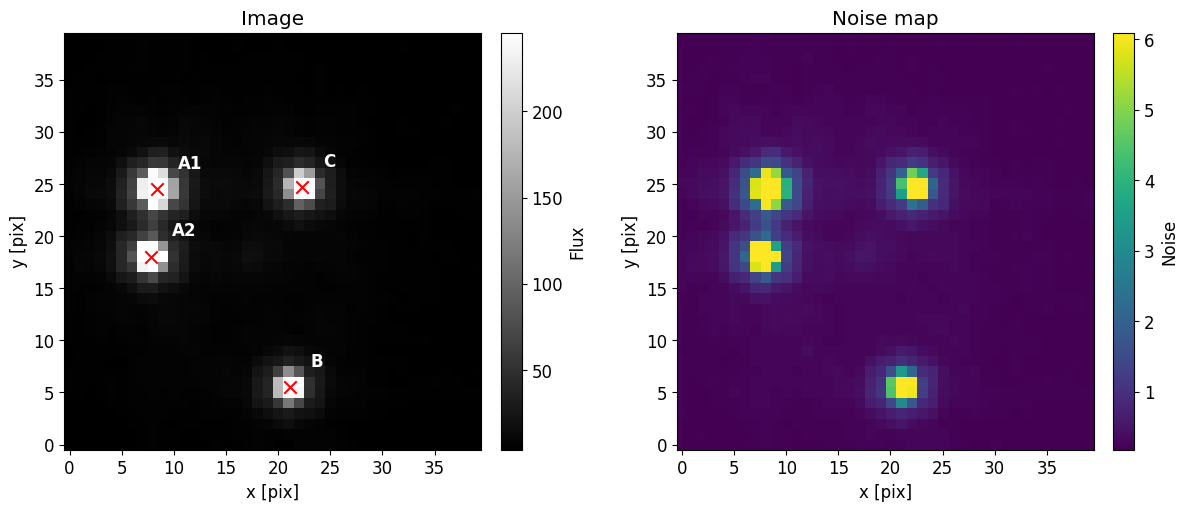

In [338]:
data = dict_result["data"]#['data_cutout']
sigma_2 = dict_result['sigma2']#['sigma2']
image_positions = dict_result["coord_pix_images"]
image_names = dict_result["images_names"]
coord_pix_images_dict = dict_result["coord_pix_images_dict"]
coord_pix_non_images = dict_result["coord_pix_non_images"]
fig, ax = plot_image_and_noisemap(
    data=data[0],
    noisemaps=sigma_2[0],
    image_positions=image_positions,
    image_names=image_names,
    vmin=np.nanpercentile(data, 1),
    vmax=np.nanpercentile(data, 99),
    noise_vmin=np.nanpercentile(sigma_2, 1),
    noise_vmax=np.nanpercentile(sigma_2, 99),)
plt.show()
if len(narrow_psfs.shape)==2:
	narrow_psfs = narrow_psfs[None,:]


In [359]:
norm_factor,data,sigma_2,*_, = normalize_data_error(data,1/sigma_2,print_=False)#stars

In [360]:
im_size = data.shape[1]
offset = (im_size-1) / 2.
# while we're at it extract the x and y positions separately
xs = image_positions[:,0] - offset
ys = image_positions[:,1] - offset
#pt1_non_lens = coord_pix_non_images[0] - offset
#pt2_non_lens = coord_pix_non_images[1] - offset



In [361]:
data.shape[1]

40

In [362]:
# pt2_non_lens

In [363]:
# # #sigma_2 = noisemaps**2
# norm = data[0].max() / 100.
# data /= norm
# sigma_2 /= norm**2 

In [364]:
# sigma_2.shape

In [365]:
# [pts_amp[j]  for i in range(1) for j in range(len(pts_amp))]

In [368]:
# data

In [369]:

# initial_c_x = np.array([]) 
# initial_c_y = np.array([]) 

# model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(data, 
#                                                                        noisemaps**2, 
#                                                                        narrow_psfs, 
#                                                                        initial_c_x,
#                                                                        initial_c_y, 
#                                                                        subsampling_factor)

# parameters = ParametersDeconv(kwargs_init, 
#                               kwargs_fixed, 
#                               kwargs_up=kwargs_up, 
#                               kwargs_down=kwargs_down)
# # compute noise level in starlet space
# W = propagate_noise(model, noisemaps, kwargs_init, wavelet_type_list=['starlet'], 
#                     method='MC', num_samples=500, seed=1, likelihood_type='chi2', 
#                     verbose=False, upsampling_factor=subsampling_factor)[0]

# optim = Optimizer(loss, parameters, method=method_deconv )
# best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(max_iterations=n_iter, restart_from_init=True, init_learning_rate=1e-3) 

# # Printing final results
# kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
# print(kwargs_final)
# fig = pltf.plot_loss(extra_fields['loss_history'])

# # Retrieving different elements of the deconvolved image
# epoch = 0
# output = model.model(kwargs_final)[epoch]
# deconv, h = model.getDeconvolved(kwargs_final, epoch)

# data_show = data[epoch,:,:] 

# dif = data_show - output
# rr = np.abs(dif) / np.sqrt((noisemaps**2)[epoch,:,:])

# fig, axs = plt.subplots(2, 2, figsize=(15,8))
# fraction = 0.046
# pad = 0.04
# font_size = 10
# ticks_size = 6

# from astropy.visualization import (imshow_norm, MinMaxInterval,
#                                    SqrtStretch, AsinhStretch)
# stretch = AsinhStretch

# plt.rc('font', size=font_size)           
# axs[0,0].set_title('Data', fontsize=8)
# axs[0,0].tick_params(axis='both', which='major', labelsize=ticks_size)

# axs[0,1].set_title('Deconvolved image', fontsize=8)
# axs[0,1].tick_params(axis='both', which='major', labelsize=ticks_size)

# axs[1,0].set_title('Convolving back', fontsize=8)
# axs[1,0].tick_params(axis='both', which='major', labelsize=ticks_size)

# axs[1,1].set_title('Map of relative residuals', fontsize=8)
# axs[1,1].tick_params(axis='both', which='major', labelsize=ticks_size)


# im, norm = imshow_norm(data_show, axs[0,0], interval=MinMaxInterval(), stretch=stretch())
# fig.colorbar(im, ax=axs[0,0], fraction=fraction, pad=pad)
# im2, _ = imshow_norm(h, axs[0,1], interval=MinMaxInterval(), stretch=stretch())
# fig.colorbar(im2, ax=axs[0,1], fraction=fraction, pad=pad)
# fig.colorbar(axs[1,0].imshow(output, norm=norm), ax=axs[1,0], fraction=fraction, pad=pad)
# fig.colorbar(axs[1,1].imshow(rr), ax=axs[1,1], fraction=fraction, pad=pad) 
# plt.show()

In [370]:
# {'kwargs_analytic': {'a': Array([4.6511574, 2.901589 , 4.3529863, 4.171639 ], dtype=float32),
#   'c_x': Array([ 42.97038   ,   0.07520159,  33.213802  , -29.741405  ], dtype=float32),
#   'c_y': Array([ -1.4135003, -26.412386 ,  19.628275 ,  35.051342 ], dtype=float32),
#   'dx': Array([0.], dtype=float32),
#   'dy': Array([0.], dtype=float32),
#   'alpha': Array([0.], dtype=float32)},
#  'kwargs_background': {'mean': Array([0.], dtype=float32),
#   'h': Array([0.03919113, 0.04170924, 0.03714106, ..., 0.01399203, 0.03667016,
#          0.00378083], dtype=float32)},
#  'kwargs_sersic': {'amp': Array([44.300323, 46.899933], dtype=float32),
#   'R_sersic': Array([0.9748651 , 0.33657593], dtype=float32),
#   'n_sersic': Array([4.4194694 , 0.38233557], dtype=float32),
#   'center_x': Array([ 3.5837872, 54.158848 ], dtype=float32),
#   'center_y': Array([ 2.0629416, 44.56607  ], dtype=float32),
#   'e1': Array([-0.35586634, -0.763041  ], dtype=float32),
#   'e2': Array([-0.8013654, -0.7576444], dtype=float32)}}

In [371]:
# initial_c_x

In [372]:
# kwargs_init["kwargs_sersic"]

In [373]:
# kwargs_final

In [374]:
# subsampling_factor

In [397]:
# subsampling_factor

{'kwargs_analytic': {'c_x': array([-11.0959231 ,   2.78808893, -11.69611723,   1.61423982]), 'c_y': array([  5.01038658,   5.22017489,  -1.47051067, -13.95497331]), 'dx': array([0.]), 'dy': array([0.]), 'alpha': array([0.]), 'a': array([200., 200., 200., 200.])}, 'kwargs_background': {'h': array([0., 0., 0., ..., 0., 0., 0.], shape=(25600,)), 'mean': array([0.])}, 'kwargs_sersic': {'amp': [], 'R_sersic': [], 'n_sersic': [], 'center_x': [], 'center_y': [], 'e1': [], 'e2': []}}


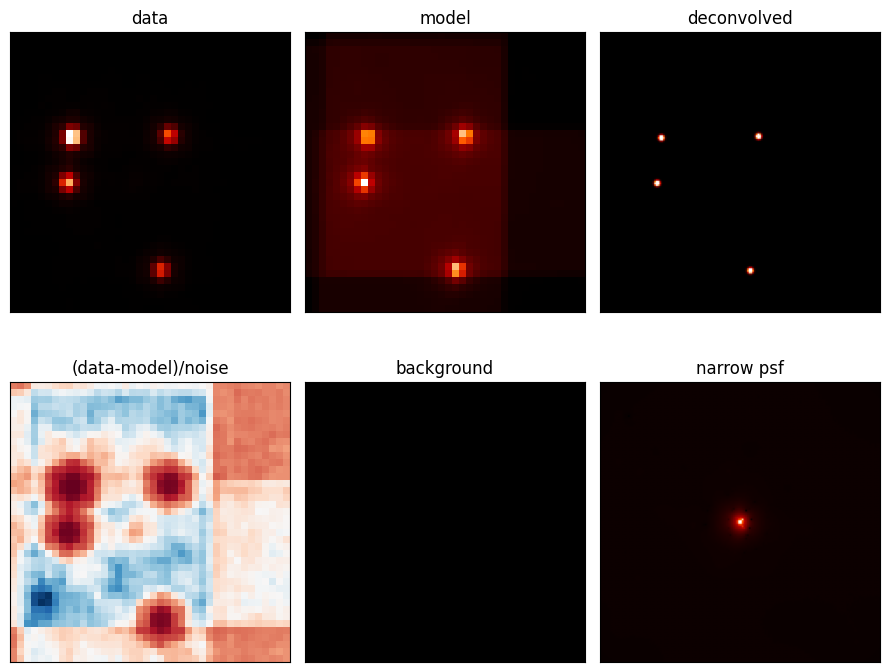

In [395]:
# Parameter initialization

# positions of the point sources.
# they are given starting from the center
# of the image, in pixels.
# we can measure them from the plot above.
# (matplotlib gives us the coordinates upon hovering)
# then we subtract half the size of the image to center them.
# offset = (im_size-1)/2.
initial_c_x = xs
initial_c_y =ys

# we give the inital amplitude for one epoch. The setup function
# replicates them for all epochs. You can fine tune this later
# if you feel like your amplitudes are widely different on an
# epoch-per-epoch basis.
#pts_amp = np.asarray([5500, 5000, 5000, 3000]) / norm
#initial_a = [pts_amp[j]  for i in range(1) for j in range(len(pts_amp))]
brightnesses = len(data) * 4 * [2e4]
#len(data) * 4 * [np.max(data)]
# the setup function gives us a model class, with
# dictionaries of parameters.
model, kwargs_init, kwargs_up, kwargs_down, kwargs_fixed = setup_model(data, 
                                                                       sigma_2, 
                                                                       narrow_psfs, 
                                                                       initial_c_x,
                                                                       initial_c_y,
                                                                       subsampling_factor,
                                                                       initial_a = brightnesses,
                                                                       N_sersic = 0)

#let's rise a bit the Sersic parameters, index 0 refers to the first sersic: 
# kwargs_init['kwargs_sersic']['amp'][0] = 2e4/100
# kwargs_init['kwargs_sersic']['e1'][0] = -0.1
# kwargs_init['kwargs_sersic']['e2'][0] = -0.1
# kwargs_init['kwargs_sersic']['center_x'][0] = pt1_non_lens[0]
# kwargs_init['kwargs_sersic']['center_y'][0] = pt1_non_lens[1]

# # we can modify them if we want to.
# # for example, let's shift the second epoch slightly
# # to match our data better:



# kwargs_init['kwargs_sersic']['amp'][1] = 2e4/100
# kwargs_init['kwargs_sersic']['e1'][1] = -0.1
# kwargs_init['kwargs_sersic']['e2'][1] = -0.1
# kwargs_init['kwargs_sersic']['center_x'][1] = pt2_non_lens[0]
# kwargs_init['kwargs_sersic']['center_y'][1] = pt2_non_lens[1]


# kwargs_init['kwargs_analytic']['dx'][0] = 0
# kwargs_init['kwargs_analytic']['dy'][0] = 0 



parameters = ParametersDeconv(kwargs_init, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

# print our initial parameters:
print(kwargs_init)
view_deconv_model(model, kwargs_init, data, sigma_2)

Step 1, fixing : ['pts-source-astrometry', 'background']
Step 1/2 took  5 seconds
Kwargs partial at step 1/2 {'kwargs_analytic': {'a': Array([1.7300589, 7.1410003, 6.361219 , 5.4022875], dtype=float32), 'c_x': Array([-11.095923 ,   2.788089 , -11.696117 ,   1.6142398], dtype=float32), 'c_y': Array([  5.0103865,   5.220175 ,  -1.4705107, -13.954973 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  3160.358
Overall Reduced Chi2 :  3.9504473
Step 

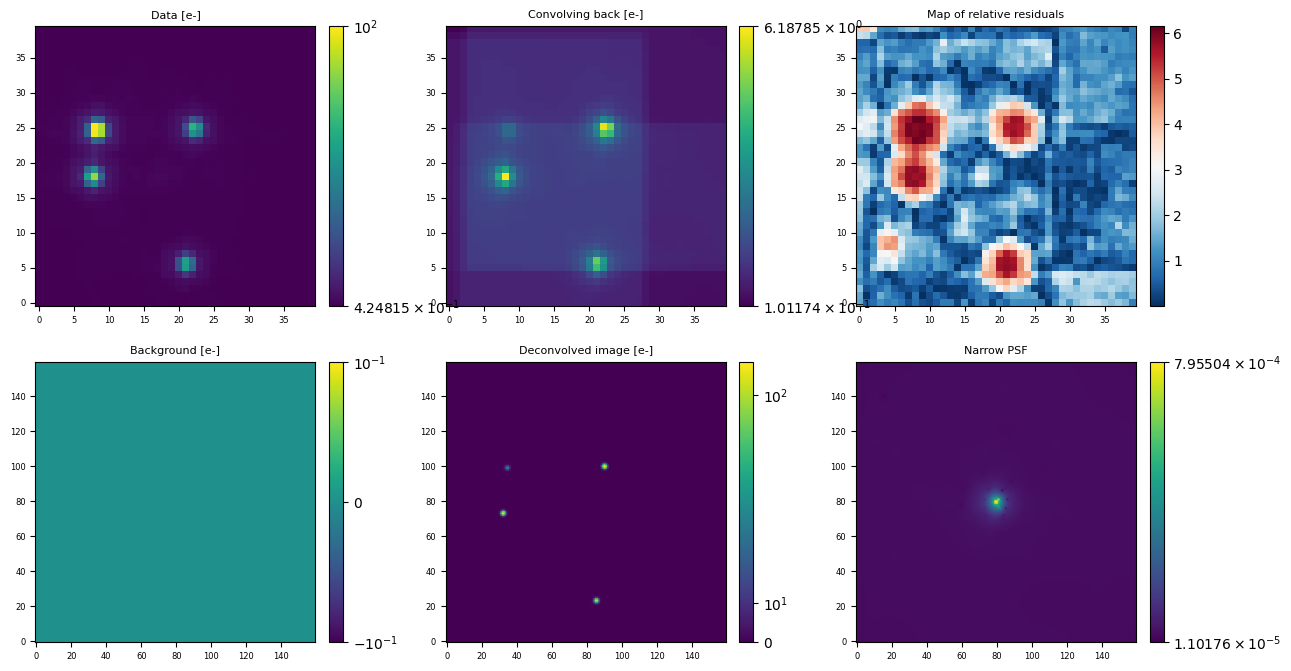

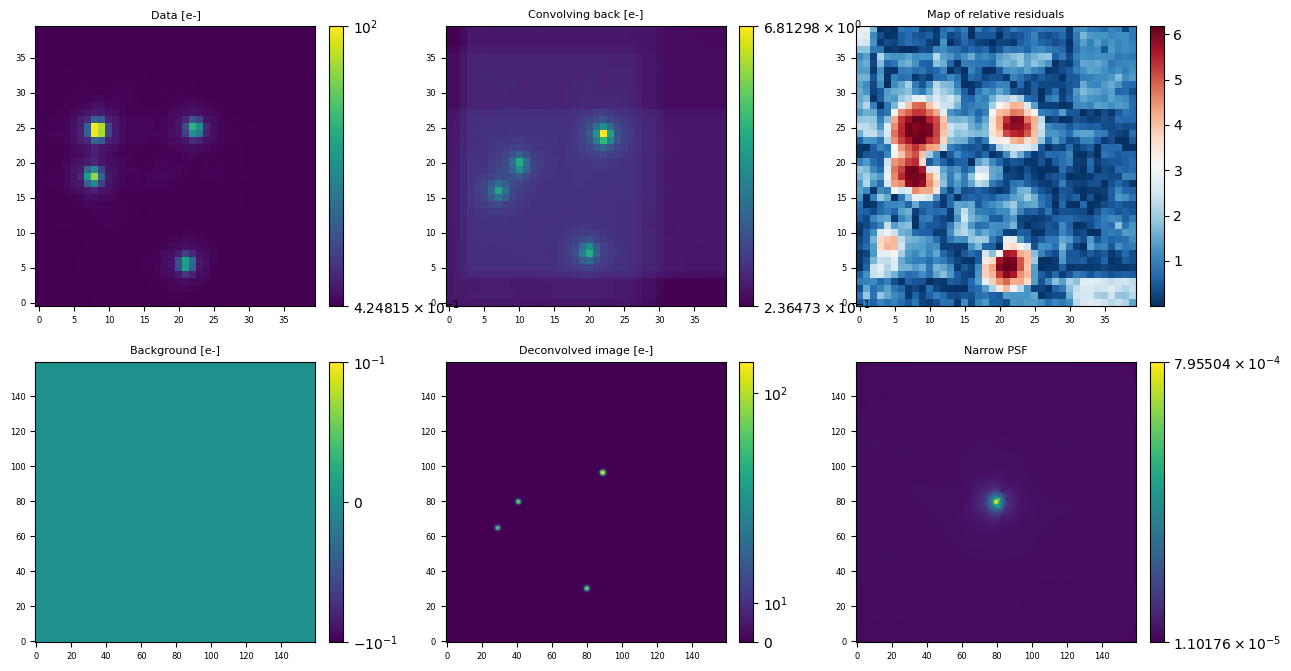

In [ ]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [
                    ['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                    ['background'], #step 2: release astrometry, keep the pixelated background constant.
        ]
    
#Since we have no regularisation, we can use 'l-bfgs-b'. 
optim_list = ['l-bfgs-b','l-bfgs-b']

#l-fgs-b, you can use the following parameters: 
kwargs_lbfgs = {'maxiter':50}

#list of configuration for the optimsers 
kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

#we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
prior_list=[None,None]

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma_2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 0, lambda_hf =0, 
                                                                                    lambda_positivity_ps=100, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

Step 1, fixing : ['background']
Step 1/3 took  4 seconds
Kwargs partial at step 1/3 {'kwargs_analytic': {'a': Array([4.1622944, 7.2972136, 3.6842287, 4.469672 ], dtype=float32), 'c_x': Array([ -9.5372305,   2.5188665, -12.484783 ,   0.2490123], dtype=float32), 'c_y': Array([  0.1835148,   4.3275156,  -3.5598762, -12.212673 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  2865.346
Overall Reduced Chi2 :  3.5816824
Step 2, fixing : ['pts-source-

optax.adabelief: 100%|██████████| 100/100 [00:03<00:00, 25.89it/s]


Step 2/3 took  5 seconds
Kwargs partial at step 2/3 {'kwargs_analytic': {'a': Array([4.1608157, 7.2979164, 3.684731 , 4.4699535], dtype=float32), 'c_x': Array([ -9.5372305,   2.5188665, -12.484783 ,   0.2490123], dtype=float32), 'c_y': Array([  0.1835148,   4.3275156,  -3.5598762, -12.212673 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  2865.3464
Overall Reduced Chi2 :  3.5816832
Step 3, fixing : []


optax.adabelief: 100%|██████████| 100/100 [00:03<00:00, 25.85it/s]


Step 3/3 took  5 seconds
Kwargs partial at step 3/3 {'kwargs_analytic': {'a': Array([4.1605544, 7.298019 , 3.6848903, 4.469959 ], dtype=float32), 'c_x': Array([ -9.537092  ,   2.5186684 , -12.484303  ,   0.24845514], dtype=float32), 'c_y': Array([  0.18339114,   4.32768   ,  -3.5596836 , -12.213803  ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  2865.347
Overall Reduced Chi2 :  3.5816836


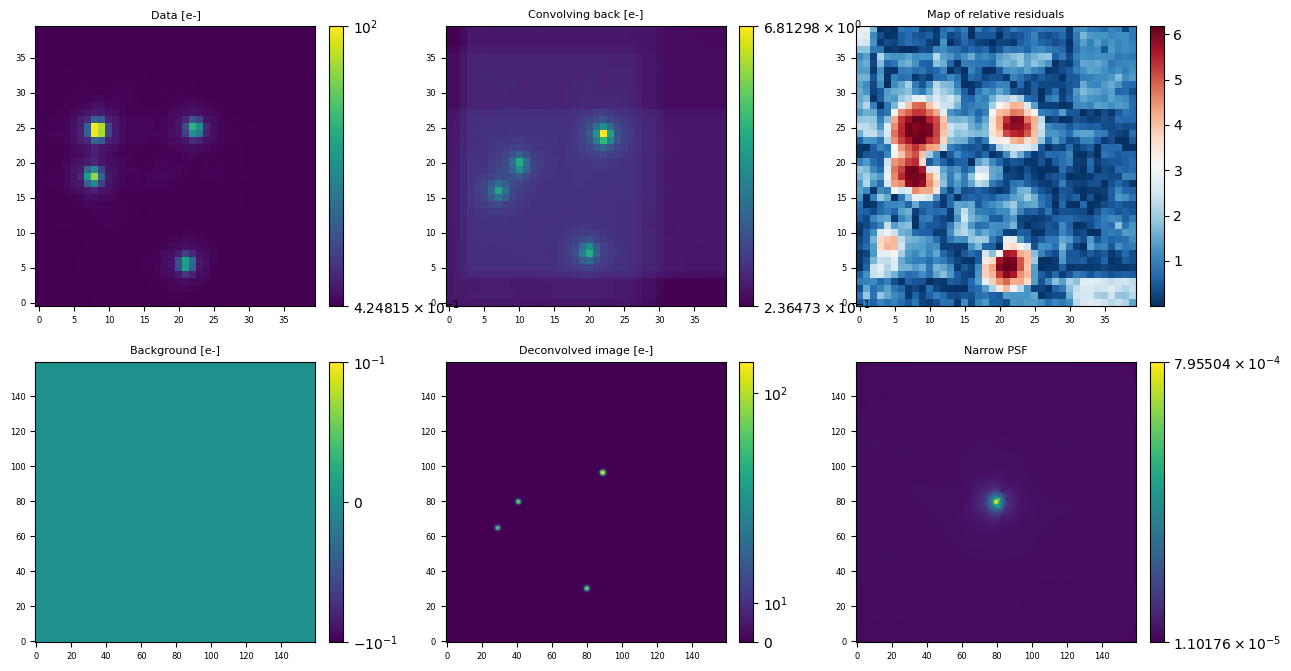

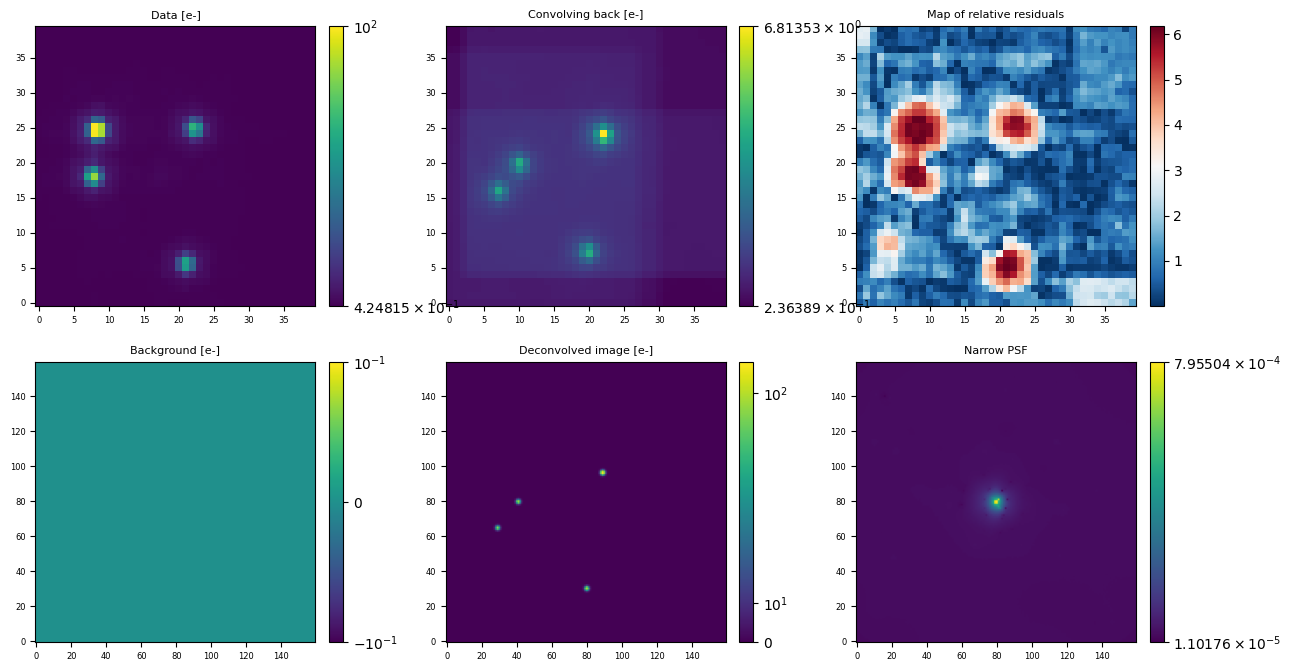

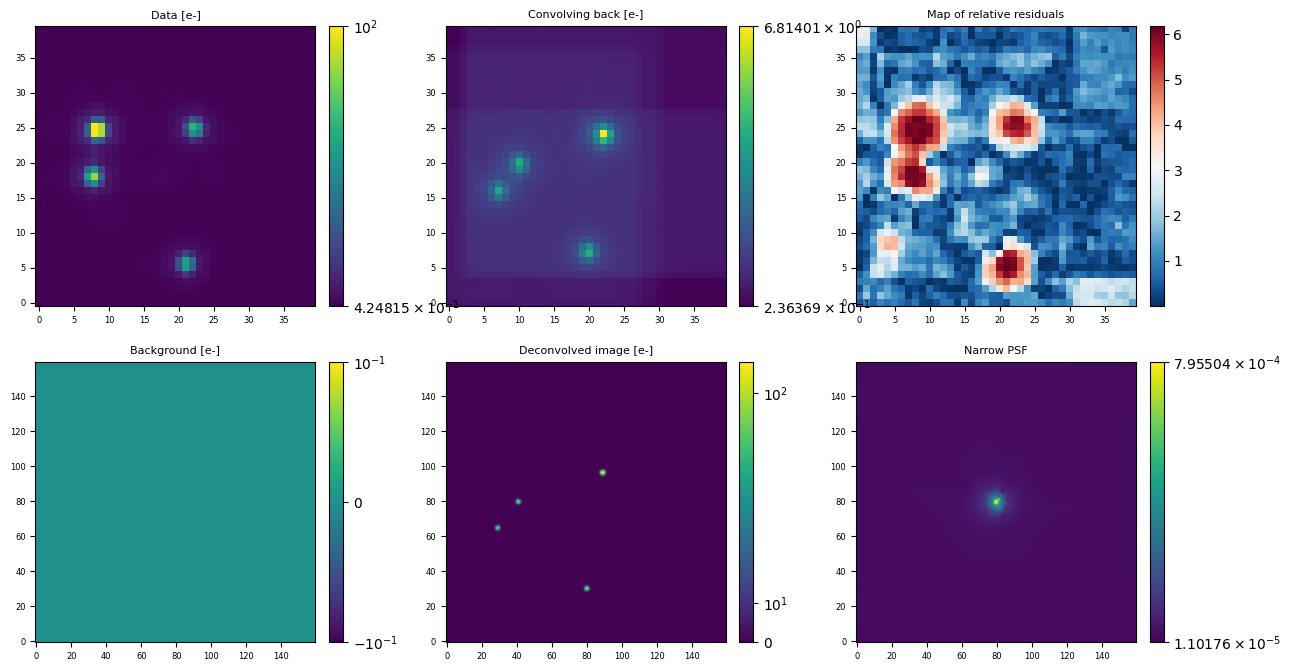

In [399]:
model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma_2, narrow_psfs, 
                                                                                                                 subsampling_factor,lambda_scales = 5, lambda_hf =5 )

In [387]:
# #Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
# fitting_sequence = [['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
#                     ['background'], #step 2: release astrometry, keep the pixelated background constant.
#         ]
    
# #Since we have no regularisation, we can use 'l-bfgs-b'. 
# optim_list = ['l-bfgs-b','l-bfgs-b']

# #l-fgs-b, you can use the following parameters: 
# kwargs_lbfgs = {'maxiter':50}

# #list of configuration for the optimsers 
# kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

# #we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
# prior_list=[None,None]

# model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma_2, narrow_psfs, subsampling_factor,
#                                                                                     fitting_sequence = fitting_sequence,
#                                                                                     optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
#                                                                                     #lambda_scales = 0, lambda_hf =0, 
#                                                                                     lambda_positivity_ps=100, #we don't want the poitn source to be negative
#                                                                                     prior_list = prior_list,
#                                                                                     adjust_sky = False, #Sky has already been subtracted
#                                                                                     noise_propagation = 'MC')

In [378]:
from pprint import pprint

{'kwargs_analytic': {'a': Array([4.1605544, 7.298019 , 3.6848903, 4.469959 ], dtype=float32),
                     'alpha': Array([0.], dtype=float32),
                     'c_x': Array([ -9.537092  ,   2.5186684 , -12.484303  ,   0.24845514], dtype=float32),
                     'c_y': Array([  0.18339114,   4.32768   ,  -3.5596836 , -12.213803  ], dtype=float32),
                     'dx': Array([0.], dtype=float32),
                     'dy': Array([0.], dtype=float32)},
 'kwargs_background': {'h': Array([0., 0., 0., ..., 0., 0., 0.], dtype=float32),
                       'mean': Array([0.], dtype=float32)},
 'kwargs_sersic': {'R_sersic': Array([], shape=(0,), dtype=float32),
                   'amp': Array([], shape=(0,), dtype=float32),
                   'center_x': Array([], shape=(0,), dtype=float32),
                   'center_y': Array([], shape=(0,), dtype=float32),
                   'e1': Array([], shape=(0,), dtype=float32),
                   'e2': Array([], shape=(0,),

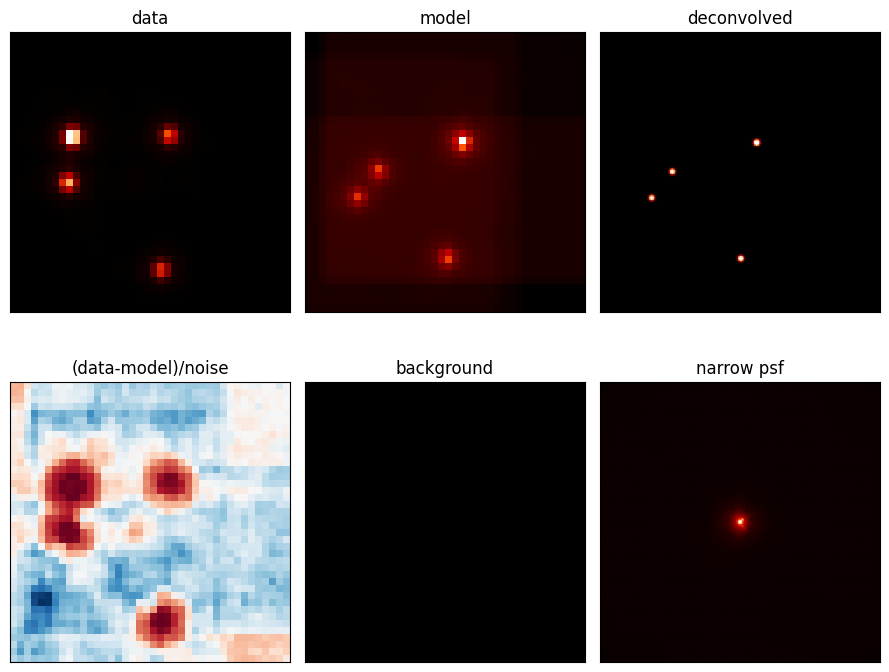

In [393]:
# Printing and visualizing the partial results
kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
pprint(kwargs_partial)
view_deconv_model(model, kwargs_partial, data, sigma_2)

Step 1, fixing : ['pts-source-astrometry']


optax.adabelief: 100%|██████████| 500/500 [00:26<00:00, 18.88it/s] 


Step 1/3 took 28 seconds
Kwargs partial at step 1/3 {'kwargs_analytic': {'a': Array([ 4.3806401e-03,  6.0081021e-03, -9.1030102e-05,  1.4297656e-02],      dtype=float32), 'c_x': Array([ -9.5372305,   2.5188665, -12.484783 ,   0.2490123], dtype=float32), 'c_y': Array([  0.1835148,   4.3275156,  -3.5598762, -12.212673 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.05992778], dtype=float32), 'h': Array([0.3642009 , 0.5680299 , 0.66746163, ..., 0.88635755, 0.720446  ,
       0.44135842], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  3811.793
Overall

optax.adabelief: 100%|██████████| 500/500 [00:05<00:00, 95.79it/s] 


Step 2/3 took  6 seconds
Kwargs partial at step 2/3 {'kwargs_analytic': {'a': Array([-2.1002529, -1.3423384, -2.2095072, -0.7801617], dtype=float32), 'c_x': Array([ 0.8004972 ,  8.838384  , -4.226754  , -0.97468406], dtype=float32), 'c_y': Array([ -1.1770428,   8.296839 ,   1.1657935, -18.052845 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.04107189], dtype=float32), 'h': Array([0.3642009 , 0.5680299 , 0.66746163, ..., 0.88635755, 0.720446  ,
       0.44135842], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  3123.266
Overall Reduced Chi2 :  3.90

optax.adabelief: 100%|██████████| 500/500 [00:26<00:00, 18.78it/s]


Step 3/3 took 29 seconds
Kwargs partial at step 3/3 {'kwargs_analytic': {'a': Array([0.00121535, 0.00108088, 0.00041273, 0.00177893], dtype=float32), 'c_x': Array([ 1.52871  ,  9.284988 , -4.2531357, -0.4471675], dtype=float32), 'c_y': Array([ -0.811516 ,   8.162717 ,   1.3229603, -18.828775 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.02046577], dtype=float32), 'h': Array([0.11227906, 0.17905997, 0.21334876, ..., 0.7413604 , 0.5731961 ,
       0.3171629 ], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  2630.9019
Overall Reduced Chi2 :  3.19487

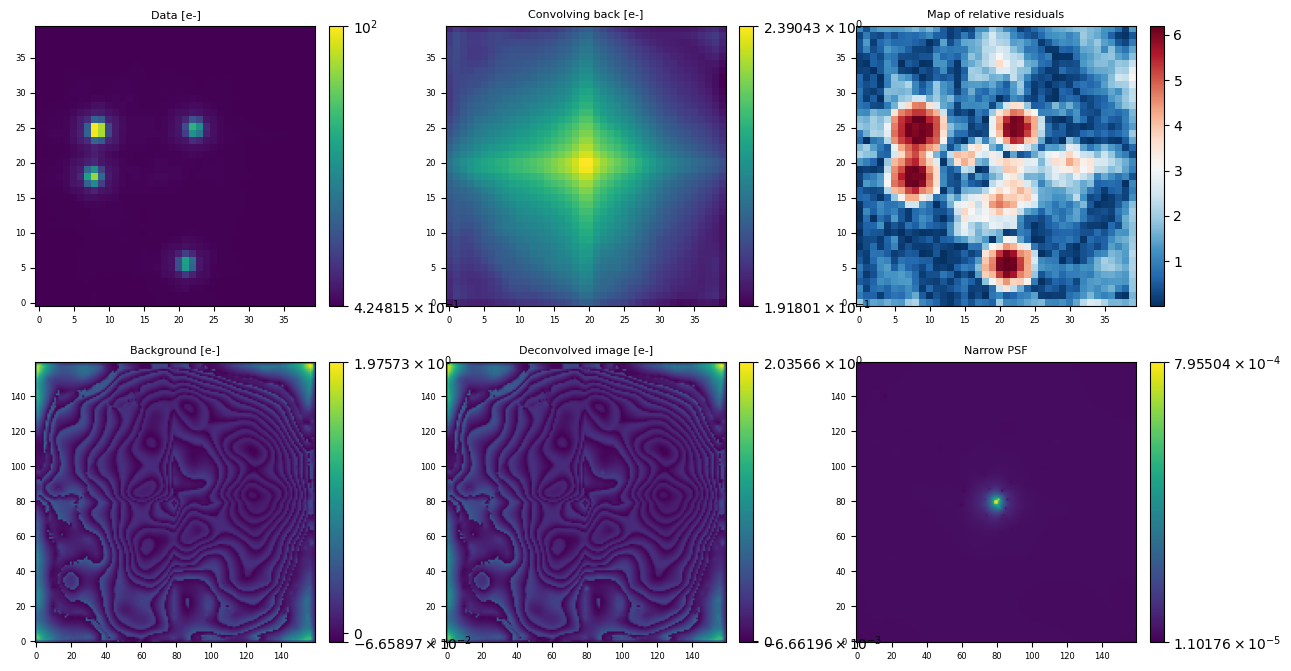

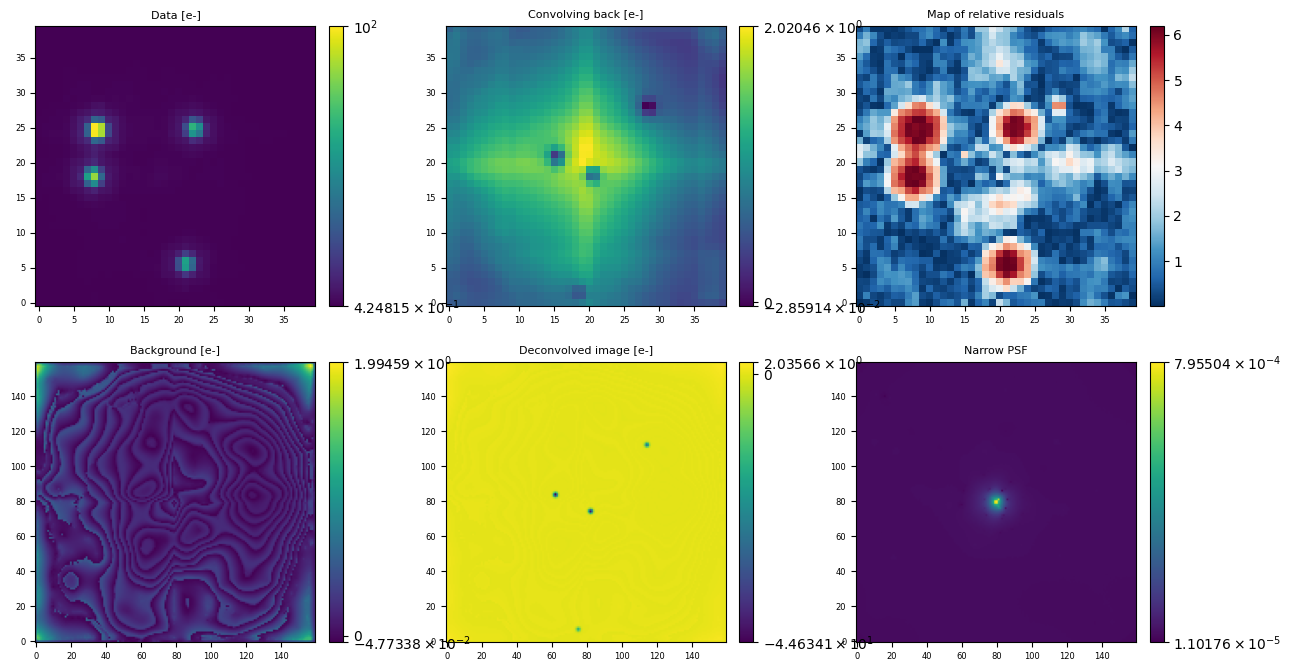

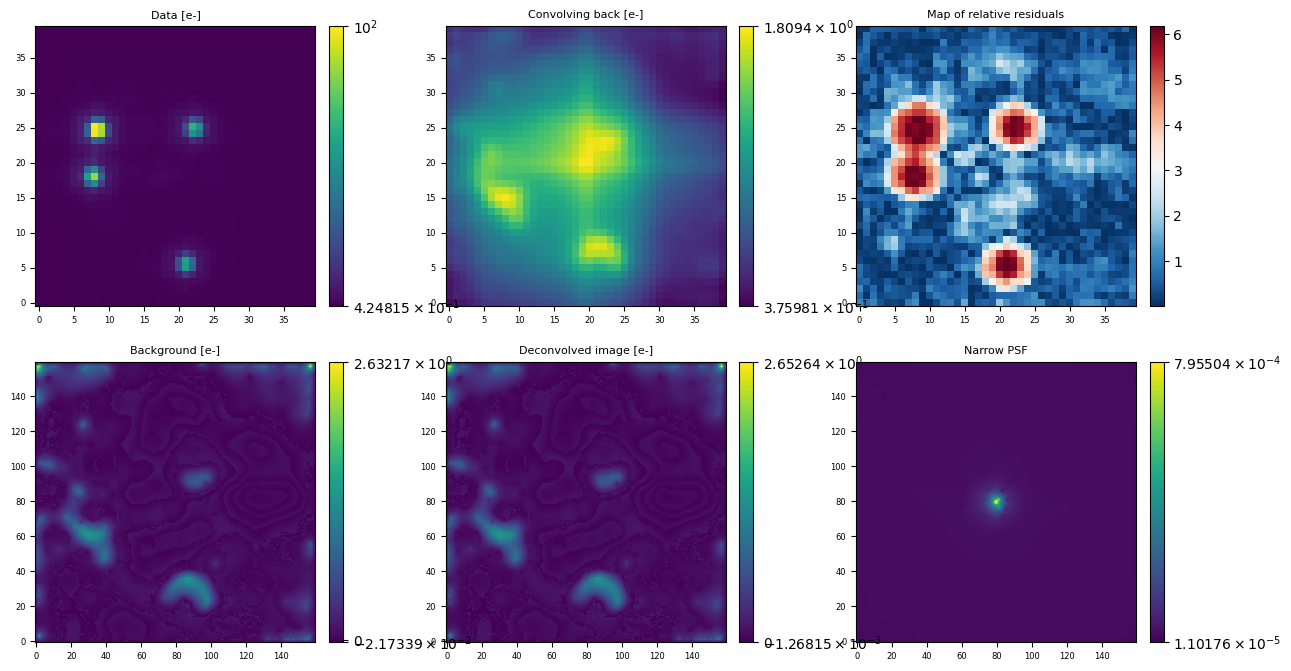

In [ ]:
#Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
fitting_sequence = [['pts-source-astrometry'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
                    ['background'], #step 2: release astrometry, keep the pixelated background constant.
        []]
    
    
optim_list = ['adabelief','adabelief',""]
kwargs_optax1 = {'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 5e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optax2 = {
        'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }
kwargs_optax2 = {
        'max_iterations': 500, 'min_iterations': None,
        'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
        'restart_from_init': False, 'stop_at_loss_increase': False,
        'progress_bar': True, 'return_param_history': True
    }

kwargs_optim_list = [kwargs_optax1, kwargs_optax2,kwargs_optax2] 
prior_list=[None,None,None]

parameters = ParametersDeconv(kwargs_partial, 
                              kwargs_fixed, 
                              kwargs_up=kwargs_up, 
                              kwargs_down=kwargs_down)

model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma_2, narrow_psfs, subsampling_factor,
                                                                                    fitting_sequence = fitting_sequence,
                                                                                    optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
                                                                                    lambda_scales = 1, 
                                                                                    lambda_positivity_ps=1000, #we don't want the poitn source to be negative
                                                                                    prior_list = prior_list,
                                                                                    adjust_sky = False, #Sky has already been subtracted
                                                                                    noise_propagation = 'MC')

/home/felipe/miniconda3/envs/SFstarred/lib/python3.12/site-packages/starred/procedures/deconvolution_routines.py:55: UserWarning: No optimiser kwargs provided. Default configuration is used.
  warnings.warn('No optimiser kwargs provided. Default configuration is used.')


Step 1, fixing : ['background']
Step 1/3 took  0 seconds
Kwargs partial at step 1/3 {'kwargs_analytic': {'a': Array([0., 0., 0., 0.], dtype=float32), 'c_x': Array([ 0.8004972 ,  8.838384  , -4.226754  , -0.97468406], dtype=float32), 'c_y': Array([ -1.1770428,   8.296839 ,   1.1657935, -18.052845 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.3642009 , 0.5680299 , 0.66746163, ..., 0.88635755, 0.720446  ,
       0.44135842], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  30412.904
Overall Reduced Chi2 :  38.01613
Ste

optax.adabelief: 100%|██████████| 100/100 [00:06<00:00, 15.09it/s]


Step 2/3 took  9 seconds
Kwargs partial at step 2/3 {'kwargs_analytic': {'a': Array([-0.07621847, -0.03702168, -0.06335279, -0.02319109], dtype=float32), 'c_x': Array([ 0.8004972 ,  8.838384  , -4.226754  , -0.97468406], dtype=float32), 'c_y': Array([ -1.1770428,   8.296839 ,   1.1657935, -18.052845 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.18639202, 0.31139526, 0.36928922, ..., 0.63574636, 0.49938223,
       0.28669292], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  2869.019
Overall Reduced Chi2 :  3.460348


optax.adabelief: 100%|██████████| 100/100 [00:03<00:00, 25.00it/s]


Step 3/3 took  6 seconds
Kwargs partial at step 3/3 {'kwargs_analytic': {'a': Array([ 2.1118633e-04, -7.7892459e-05, -5.8325689e-04,  1.2257091e-03],      dtype=float32), 'c_x': Array([ 0.25092867,  8.836295  , -4.2269397 , -0.7167645 ], dtype=float32), 'c_y': Array([ -1.1708428,   8.475491 ,   1.0067781, -17.740376 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.06343928, 0.0665149 , 0.06760174, ..., 0.3722356 , 0.28545627,
       0.15653573], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Loss :  2575.7695
Overall Reduced

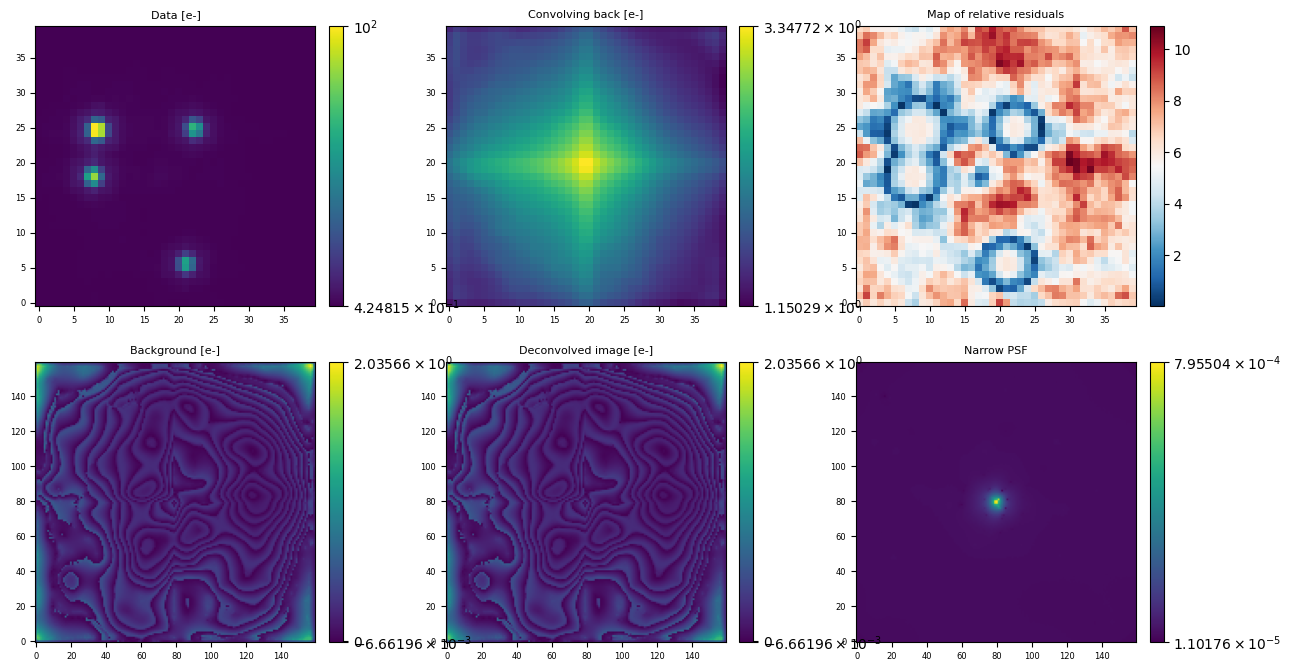

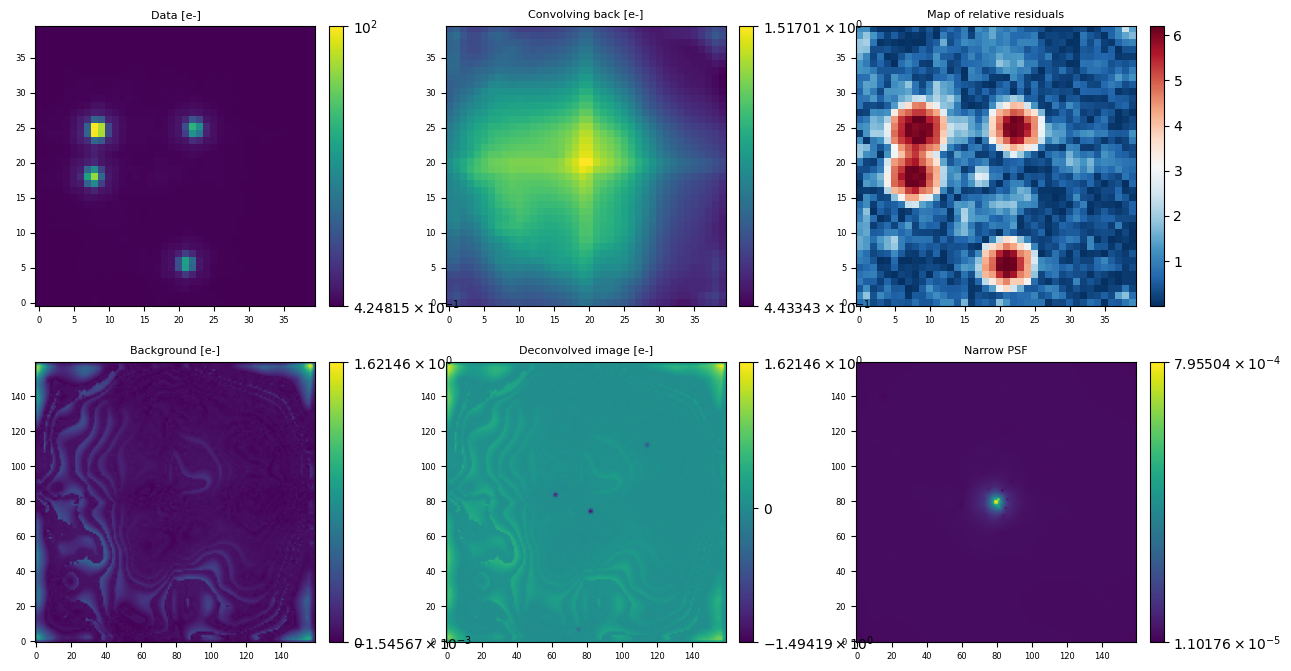

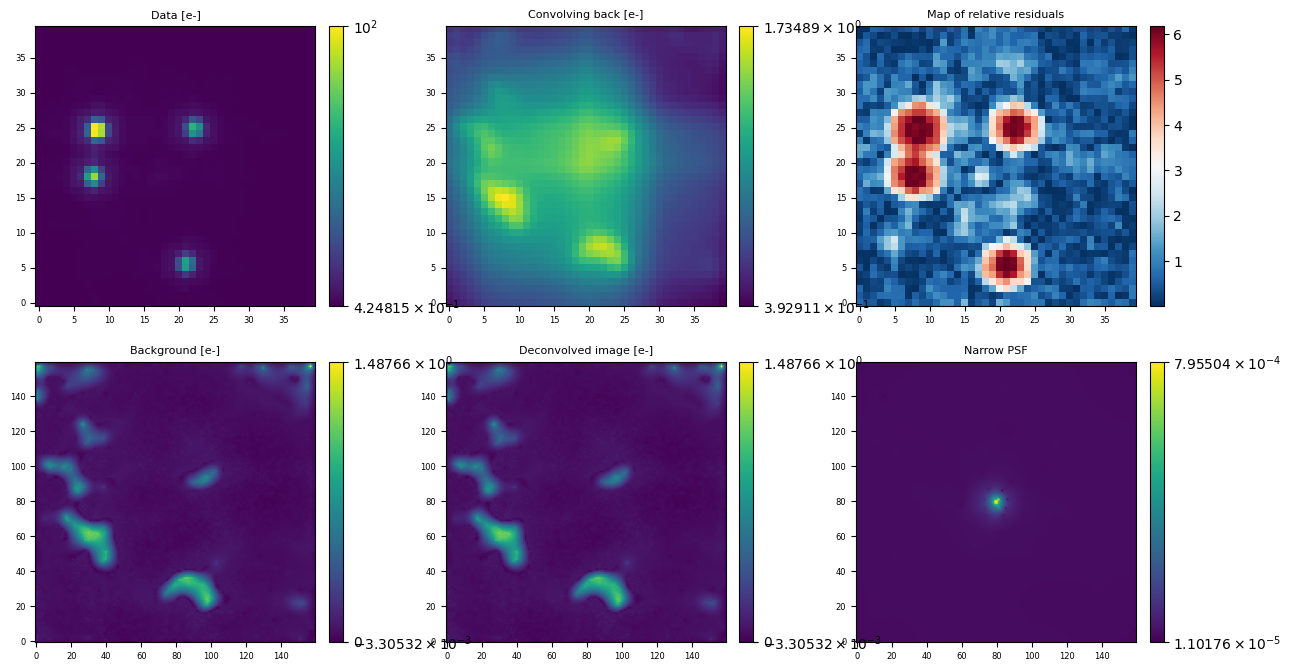

Step 1, optimiser adabelief
Step 2, optimiser adabelief
{'kwargs_analytic': {'a': Array([-2.1002529, -1.3423384, -2.2095072, -0.7801617], dtype=float32), 'c_x': Array([ 0.8004972 ,  8.838384  , -4.226754  , -0.97468406], dtype=float32), 'c_y': Array([ -1.1770428,   8.296839 ,   1.1657935, -18.052845 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([-0.04107189], dtype=float32), 'h': Array([0.3642009 , 0.5680299 , 0.66746163, ..., 0.88635755, 0.720446  ,
       0.44135842], dtype=float32)}, 'kwargs_sersic': {'amp': Array([], shape=(0,), dtype=float32), 'R_sersic': Array([], shape=(0,), dtype=float32), 'n_sersic': Array([], shape=(0,), dtype=float32), 'center_x': Array([], shape=(0,), dtype=float32), 'center_y': Array([], shape=(0,), dtype=float32), 'e1': Array([], shape=(0,), dtype=float32), 'e2': Array([], shape=(0,), dtype=float32)}}
Overall Reduced Chi2 :  3.9040825


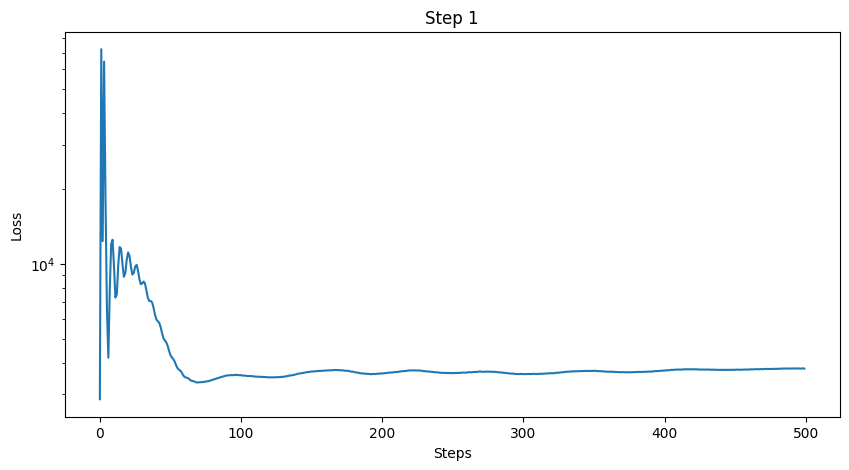

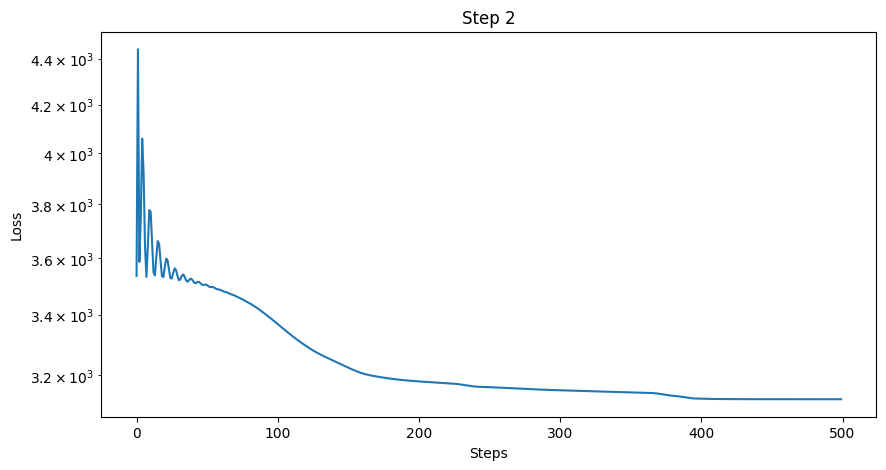

In [382]:
for i in range(len(loss_history_list)):
    print('Step %i, optimiser %s'%(i+1, optim_list[i]))
    plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
print(kwargs_final)
print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

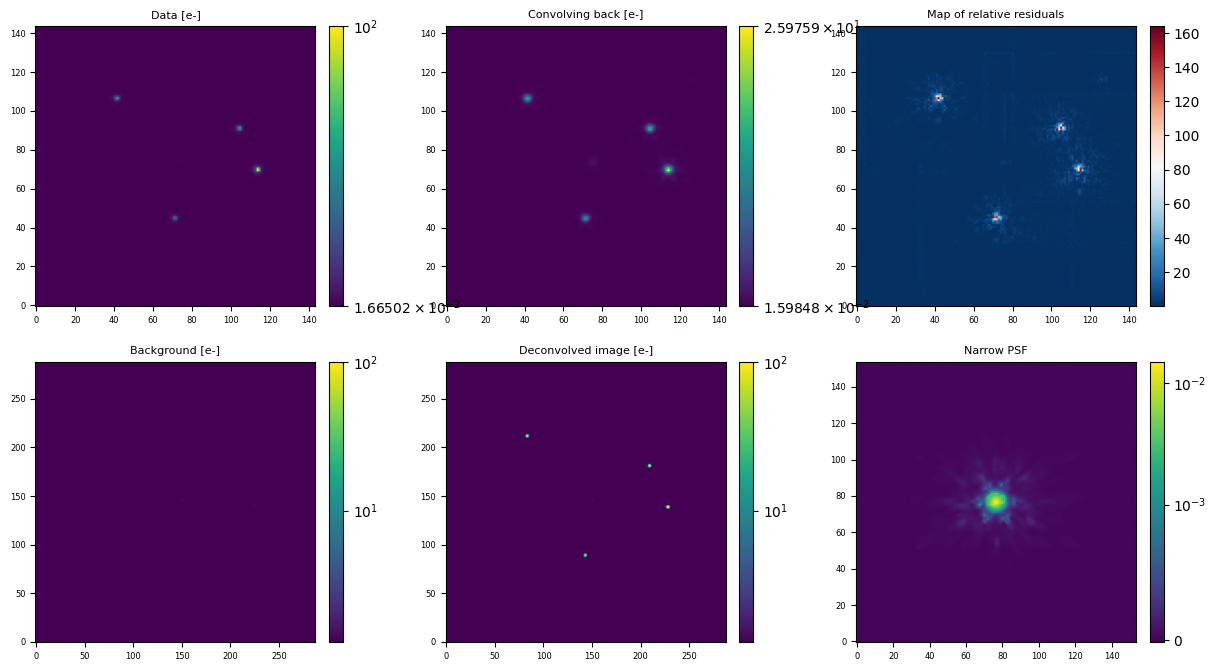

In [242]:
cut_dict = {
            'linthresh':[100,100,None,10,10,1e-3],
            'vmin':[None,None, None, 2, 2, None],
            'vmax':[None, None, None, 100,100, None],
        }
#cut of the panels, given from left to right and from top to bottom
fig2 = plot_deconvolution(model, data, sigma_2, narrow_psfs, kwargs_final, epoch = 0, units='e-', cut_dict = cut_dict)

In [125]:
# W = propagate_noise(model, noisemaps, kwargs_init, wavelet_type_list=['starlet'], 
#                     method='MC', num_samples=500, seed=1, likelihood_type='chi2', 
#                     verbose=False, upsampling_factor=subsampling_factor)[0]

# method_deconv = 'adabelief'
# loss = decLoss(data, model, parameters, noisemaps**2, 
#                regularization_terms='l1_starlet', 
#                regularization_strength_scales=lambda_scales, 
#                regularization_strength_hf=lambda_hf, W=W) 

# optim = Optimizer(loss, parameters, method=method_deconv )
# best_fit, logL_best_fit, extra_fields, runtime = optim.minimize(max_iterations=n_iter, restart_from_init=True, init_learning_rate=1e-3) 
# kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
# view_deconv_model(model, kwargs_final, data, sigma_2)

In [126]:
# #Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
# fitting_sequence = [
#                     ['pts-source-astrometry', 'background'], #step 1 : fix the astrometry and the pixelated background. Optimise the Sersic profile + photometry of the point sources
#                     ['background'], #step 2: release astrometry, keep the pixelated background constant.
#         ]
    
# #Since we have no regularisation, we can use 'l-bfgs-b'. 
# optim_list = ['l-bfgs-b','l-bfgs-b']

# #l-fgs-b, you can use the following parameters: 
# kwargs_lbfgs = {'maxiter':1000}

# #list of configuration for the optimsers 
# kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

# #we apply our astrometric prior nonly when the point sources are free (i.e. not for the second step)
# prior_list=[None,None]

# parameters = ParametersDeconv(kwargs_final, 
#                               kwargs_fixed, 
#                               kwargs_up=kwargs_up, 
#                               kwargs_down=kwargs_down)


# model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma_2, narrow_psfs, subsampling_factor,
#                                                                                     fitting_sequence = fitting_sequence,
#                                                                                     optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
#                                                                                     lambda_scales = 0, lambda_hf =0, 
#                                                                                     lambda_positivity_ps=100, #we don't want the poitn source to be negative
#                                                                                     prior_list = prior_list,
#                                                                                     adjust_sky = False, #Sky has already been subtracted
#                                                                                     noise_propagation = 'MC')
# for i in range(len(loss_history_list)):
#     print('Step %i, optimiser %s'%(i+1, optim_list[i]))
#     plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

In [127]:
# kwargs_partial = deepcopy(parameters.best_fit_values(as_kwargs=True))
# print(kwargs_partial)
# view_deconv_model(model, kwargs_partial, data, sigma_2)

In [128]:
# #Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
# fitting_sequence = [
                    
                    
#         ]
    
# #Since we have no regularisation, we can use 'l-bfgs-b'. 
# optim_list = []

# #l-fgs-b, you can use the following parameters: 


# #list of configuration for the optimsers 
# kwargs_optim_list = [kwargs_lbfgs, kwargs_lbfgs] 

In [50]:
# #Selecting the fixed components at each step, the rest is free. Format [['pts-source-astrometry','pts-source-photometry','background'],['pts-source-astrometry','pts-source-photometry'], ...]
# fitting_sequence = [['background'],
#                     ['sersic', 'pts-source-astrometry'],
#                     ['sersic', 'background'], 
#                     ['pts-source-astrometry'],]
    

# kwargs_lbfgs = {'maxiter':1000}
# kwargs_optax1 = {'max_iterations': 500, 'min_iterations': None,
#         'init_learning_rate': 5e-2, 'schedule_learning_rate': True,
#         'restart_from_init': False, 'stop_at_loss_increase': False,
#         'progress_bar': True, 'return_param_history': True
#     }
# kwargs_optax2 = {
#         'max_iterations': 500, 'min_iterations': None,
#         'init_learning_rate': 1e-2, 'schedule_learning_rate': True,
#         'restart_from_init': False, 'stop_at_loss_increase': False,
#         'progress_bar': True, 'return_param_history': True
#     }
# optim_list = ['adabelief','adabelief','adabelief','adabelief']
# kwargs_optim_list = [kwargs_optax1, kwargs_optax1,kwargs_optax1, kwargs_optax2] 
# prior_list=[None,None,None,None]

# parameters = ParametersDeconv(kwargs_final, 
#                               kwargs_fixed, 
#                               kwargs_up=kwargs_up, 
#                               kwargs_down=kwargs_down)

# model, parameters, loss, kwargs_partial_list, fig_list, LogL_list, loss_history_list = multi_steps_deconvolution(data, model, parameters, sigma_2, narrow_psfs, subsampling_factor,
#                                                                                     fitting_sequence = fitting_sequence,
#                                                                                     optim_list = optim_list, kwargs_optim_list = kwargs_optim_list,
#                                                                                     lambda_scales = lambda_scales, lambda_hf =lambda_hf, 
#                                                                                     lambda_positivity_ps=100, #we don't want the poitn source to be negative
#                                                                                     prior_list = prior_list,
#                                                                                     adjust_sky = False, #Sky has already been subtracted
#                                                                                     noise_propagation = 'MC')
# for i in range(len(loss_history_list)):
#     print('Step %i, optimiser %s'%(i+1, optim_list[i]))
#     plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))
    
# kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True)) 
# view_deconv_model(model, kwargs_final, data, sigma_2)

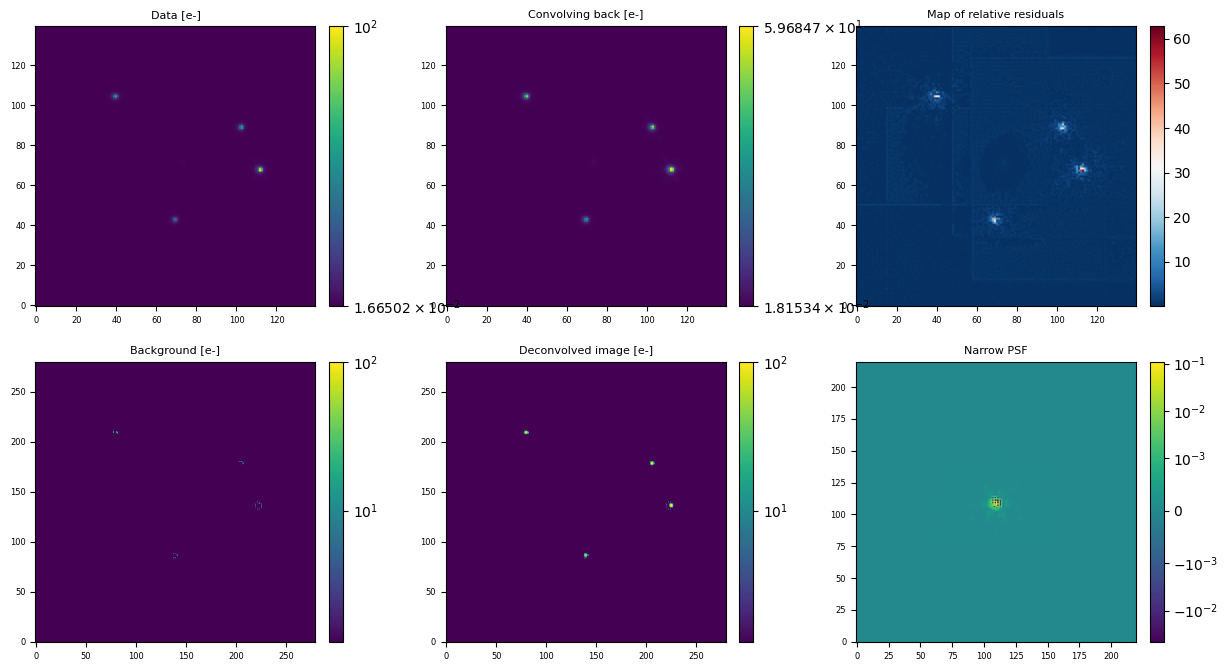

Step 1, optimiser adabelief
Step 2, optimiser adabelief
{'kwargs_analytic': {'a': Array([6.8343177, 2.9495728, 4.520098 , 4.1702704], dtype=float32), 'c_x': Array([ 42.845528  ,   0.07789089,  33.25323   , -29.66724   ], dtype=float32), 'c_y': Array([ -1.8643297, -26.716782 ,  19.226437 ,  34.661037 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.01390634, 0.00985974, 0.01124245, ..., 0.00964738, 0.00823477,
       0.00505776], dtype=float32)}, 'kwargs_sersic': {'amp': Array([8.17553  , 3.5526364], dtype=float32), 'R_sersic': Array([0., 0.], dtype=float32), 'n_sersic': Array([0.5, 0.5], dtype=float32), 'center_x': Array([ 1.0636995, 62.01846  ], dtype=float32), 'center_y': Array([ 2.0115142, 46.643288 ], dtype=float32), 'e1': Array([-0.5, -0.5], dtype=float32), 'e2': Array([-0.5, -0.5], dtype=float32)}}
Overall Reduced Chi2 :  0.8244838


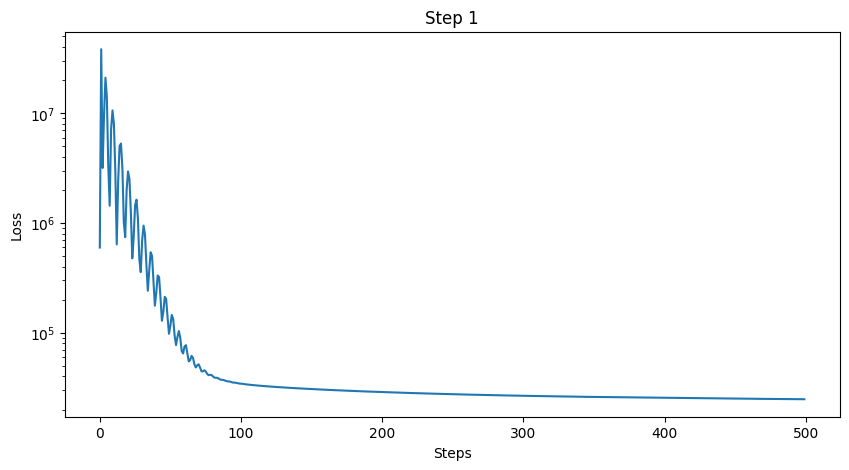

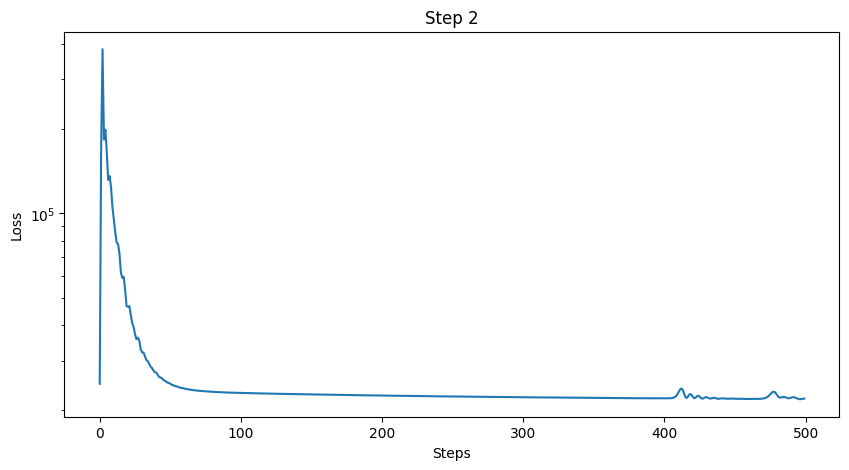

Step 1, optimiser adabelief
Step 2, optimiser adabelief
Step 3, optimiser adabelief
Step 4, optimiser adabelief
{'kwargs_analytic': {'a': Array([4.6511574, 2.901589 , 4.3529863, 4.171639 ], dtype=float32), 'c_x': Array([ 42.97038   ,   0.07520159,  33.213802  , -29.741405  ], dtype=float32), 'c_y': Array([ -1.4135003, -26.412386 ,  19.628275 ,  35.051342 ], dtype=float32), 'dx': Array([0.], dtype=float32), 'dy': Array([0.], dtype=float32), 'alpha': Array([0.], dtype=float32)}, 'kwargs_background': {'mean': Array([0.], dtype=float32), 'h': Array([0.03919113, 0.04170924, 0.03714106, ..., 0.01399203, 0.03667016,
       0.00378083], dtype=float32)}, 'kwargs_sersic': {'amp': Array([44.300323, 46.899933], dtype=float32), 'R_sersic': Array([0.9748651 , 0.33657593], dtype=float32), 'n_sersic': Array([4.4194694 , 0.38233557], dtype=float32), 'center_x': Array([ 3.5837872, 54.158848 ], dtype=float32), 'center_y': Array([ 2.0629416, 44.56607  ], dtype=float32), 'e1': Array([-0.35586634, -0.763041

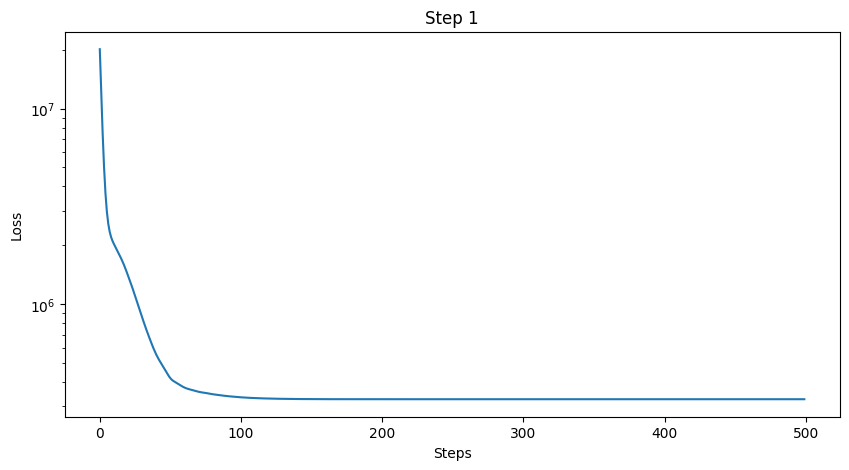

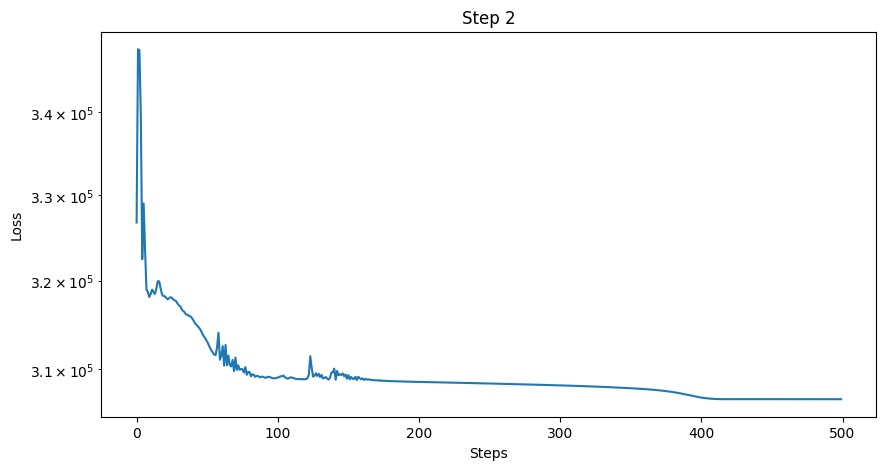

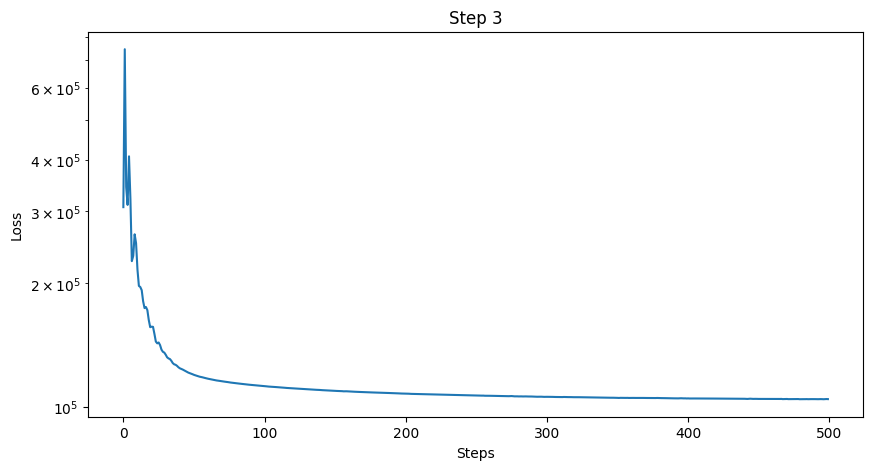

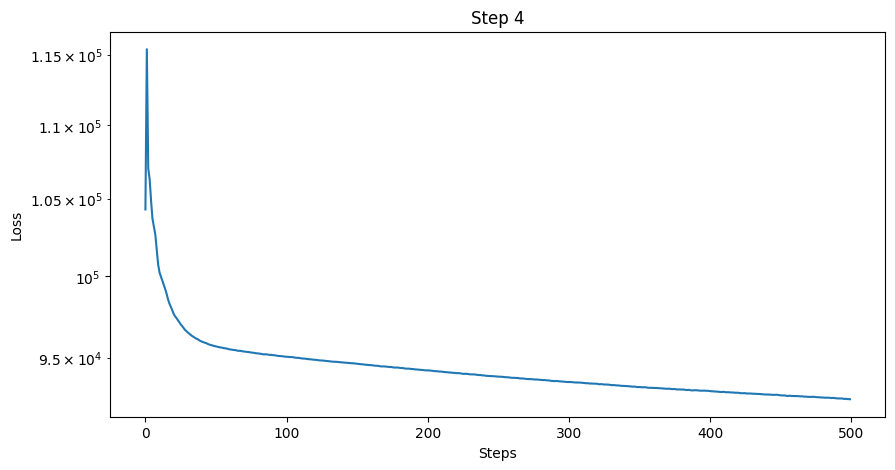

In [ ]:
# for i in range(len(loss_history_list)):
#     print('Step %i, optimiser %s'%(i+1, optim_list[i]))
#     plot_loss(loss_history=loss_history_list[i], title = 'Step %i'%(i+1))

# kwargs_final = deepcopy(parameters.best_fit_values(as_kwargs=True))
# print(kwargs_final)
# print('Overall Reduced Chi2 : ', loss.reduced_chi2(kwargs_final))

In [81]:
kwargs_final

{'kwargs_analytic': {'a': Array([4.6511574, 2.901589 , 4.3529863, 4.171639 ], dtype=float32),
  'c_x': Array([ 42.97038   ,   0.07520159,  33.213802  , -29.741405  ], dtype=float32),
  'c_y': Array([ -1.4135003, -26.412386 ,  19.628275 ,  35.051342 ], dtype=float32),
  'dx': Array([0.], dtype=float32),
  'dy': Array([0.], dtype=float32),
  'alpha': Array([0.], dtype=float32)},
 'kwargs_background': {'mean': Array([0.], dtype=float32),
  'h': Array([0.03919113, 0.04170924, 0.03714106, ..., 0.01399203, 0.03667016,
         0.00378083], dtype=float32)},
 'kwargs_sersic': {'amp': Array([44.300323, 46.899933], dtype=float32),
  'R_sersic': Array([0.9748651 , 0.33657593], dtype=float32),
  'n_sersic': Array([4.4194694 , 0.38233557], dtype=float32),
  'center_x': Array([ 3.5837872, 54.158848 ], dtype=float32),
  'center_y': Array([ 2.0629416, 44.56607  ], dtype=float32),
  'e1': Array([-0.35586634, -0.763041  ], dtype=float32),
  'e2': Array([-0.8013654, -0.7576444], dtype=float32)}}

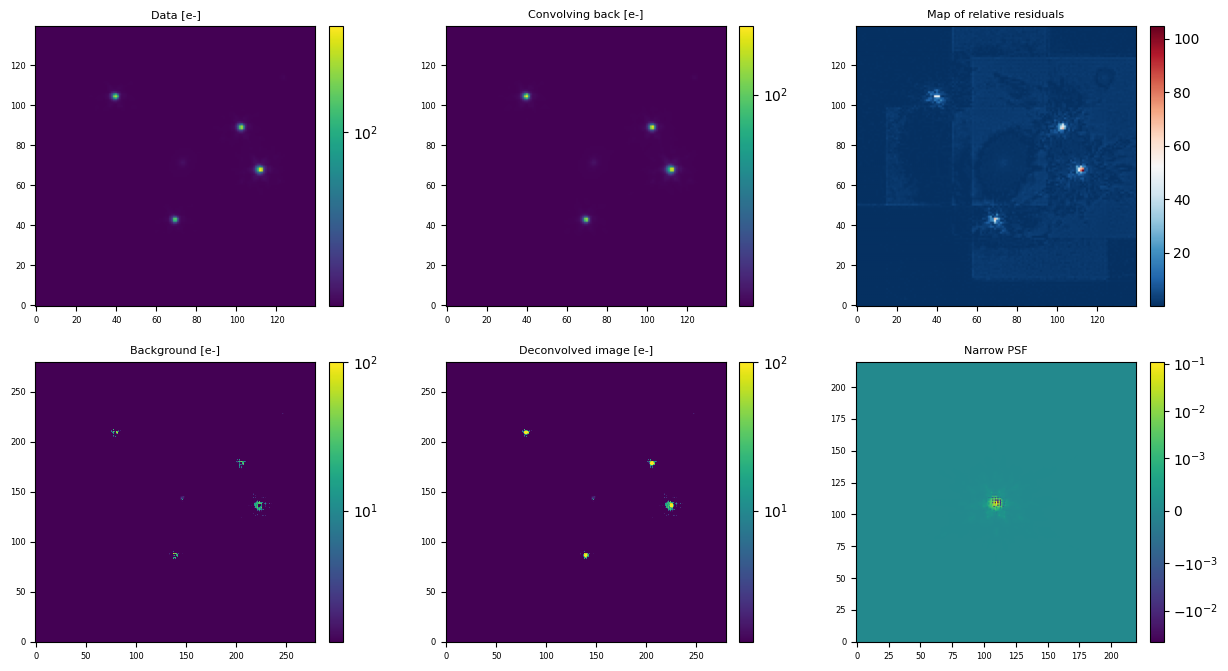

In [80]:
# Retrieving different elements of the deconvolved image
epoch = 0
output = model.model(kwargs_final)[epoch] 
deconv, h = model.getDeconvolved(kwargs_final, epoch)

cut_dict = {
            'linthresh':[100,100,None,10,10,1e-3],
            'vmin':[None,None, None, 2, 2, None],
            'vmax':[None, None, None, 100,100, None],
        }
#cut of the panels, given from left to right and from top to bottom
fig2 = plot_deconvolution(model, data, sigma_2, narrow_psfs, kwargs_final, epoch = epoch, units='e-', cut_dict = cut_dict)

: 